# MSDS 696 — Consolidated Notebook (Weeks 2–6)
### Airbnb Nightly Price Prediction — Albany, NY

This notebook merges the working notebooks from Weeks 2 through 6 into a single, end-to-end pipeline, in the order the project actually progressed:

1. **Week 2** — Vetting the dataset: what it can and can't answer
2. **Week 3** — First cleaning pass + three exploratory pricing questions
3. **Week 4** — Final cleaning, correlation/EDA, and model comparison (Lasso vs. Random Forest vs. Gradient Boosting)
4. **Week 5** — Investor-facing decision visuals (built on Week 4's cleaned data)
5. **Week 6** — Final model validation, Fourteenth Ward valuation, and limitations analysis

**Note on de-duplication:** Weeks 4, 5, and 6 in the original files each re-ran the same data-cleaning steps from scratch. To keep this notebook runnable top-to-bottom without redundant work, the cleaning pipeline appears **once**, in the Week 4 section, and the Week 5 and Week 6 sections reuse the resulting `df_available` / `df_model` / `best_pipe` variables directly. Week 3's earlier, separate cleaning pass is kept intact in its own section for the record, since it reflects a distinct point in the project's history.

---
# Week 2 — Vetting the Airbnb Pricing Dataset

# MSDS 696 · Week 2 — Vetting the Airbnb Pricing Dataset
### What this data *can* answer, and where it can't

**Question:** Which nightly price is most appropriate for an Airbnb listing given its features and
historical market information, so hosts can make informed pricing decisions before accepting future bookings?

Data: `listings.csv`, `reviews.csv`, `calendar.csv`, `neighbourhoods.csv` (Albany, NY — Inside Airbnb style export).
We organize around the same four questions from the deck: **Fit · Provenance · Limits · Feasibility.**

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# --- deck palette (same as Week 2 churn demo) ---
NAVY, CORAL, GREEN, SLATE = "#1E2761", "#E5544B", "#2E8B6F", "#64748B"
plt.rcParams.update({
    "figure.figsize": (7.2, 4.0), "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": NAVY,
    "font.size": 11, "axes.edgecolor": "#CBD5E1", "axes.labelcolor": SLATE,
})

listings = pd.read_csv("C:\\Users\\valla\\Downloads\\listings (1).csv")
reviews = pd.read_csv("C:\\Users\\valla\\Downloads\\reviews.csv")
calendar = pd.read_csv("C:\\Users\\valla\\Downloads\\calendar.csv")
neighbourhoods = pd.read_csv("C:\\Users\\valla\\Downloads\\neighbourhoods.csv")
calendar["date"] = pd.to_datetime(calendar["date"])

# price arrives as a string like "$97.00" -- clean it once, up front
listings["price_clean"] = (listings["price"].astype(str)
                            .str.replace(r"[$,]", "", regex=True)
                            .replace("nan", np.nan).astype(float))

print("listings:", listings.shape, "| reviews:", reviews.shape,
      "| calendar:", calendar.shape, "| neighbourhoods:", neighbourhoods.shape)
listings.head()

listings: (490, 91) | reviews: (29046, 6) | calendar: (178850, 5) | neighbourhoods: (16, 2)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price_clean
0,2992450,https://www.airbnb.com/rooms/2992450,20260616211424,2026-06-16,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,...,3.22,3.67,NaN,NaN,1,1,0,0,0.06,80.43
1,3820211,https://www.airbnb.com/rooms/3820211,20260616211424,2026-06-16,city scrape,Restored Precinct in Center Sq. w/Parking,Step into the charming and comfy 1BR/1BA apart...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.82,4.78,NaN,NaN,7,7,0,0,2.20,211.00
2,5651579,https://www.airbnb.com/rooms/5651579,20260616211424,2026-06-16,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",NaN,https://a0.muscache.com/pictures/b3fc42f3-6e5e...,29288920,...,4.75,4.63,NaN,NaN,2,1,1,0,3.00,97.00
3,6623339,https://www.airbnb.com/rooms/6623339,20260616211424,2026-06-16,city scrape,Center Sq. Loft in Converted Precinct w/ Parking,Step into the charming and comfy 1BR/1BA apart...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.80,4.72,NaN,NaN,7,7,0,0,2.47,160.00
4,9501054,https://www.airbnb.com/rooms/9501054,20260616211424,2026-06-16,city scrape,Spacious suite with full bath by Capital Center,Great location within walking distance to the ...,NaN,https://a0.muscache.com/pictures/45153167-d704...,29288920,...,4.77,4.68,NaN,NaN,2,1,1,0,3.71,86.00


## 1. Quick EDA — what's actually in the tables, and do the joins hold up

In [2]:
print("Do all reviews point to a real listing?   ", f"{reviews.listing_id.isin(listings.id).mean():.1%}")
print("Does all calendar data point to a real listing?", f"{calendar.listing_id.isin(listings.id).mean():.1%}")
print("Listings covered by the calendar table:      ", f"{calendar.listing_id.nunique()} / {listings.id.nunique()}")
extra = set(listings.neighbourhood_cleansed.dropna()) - set(neighbourhoods.neighbourhood.dropna())
print("neighbourhood_cleansed values missing from neighbourhoods.csv:", extra if extra else "none")

Do all reviews point to a real listing?    100.0%
Does all calendar data point to a real listing? 100.0%
Listings covered by the calendar table:       490 / 490
neighbourhood_cleansed values missing from neighbourhoods.csv: none


In [3]:
print("Rows, cols:", listings.shape)
print("\nPrice (our target) summary:")
print(listings.price_clean.describe())
print(f"\nprice is missing for {listings.price_clean.isna().sum()} / {len(listings)} listings")
miss = listings.isna().sum().sort_values(ascending=False)
print("\nTop missing columns:")
print(miss[miss > 0].head(15))

Rows, cols: (490, 91)

Price (our target) summary:
count     458.000000
mean      177.127293
std       157.348920
min        13.180000
25%        90.000000
50%       145.665000
75%       209.625000
max      1701.000000
Name: price_clean, dtype: float64

price is missing for 32 / 490 listings

Top missing columns:
host_verifications              490
host_since                      490
neighbourhood_group_cleansed    490
neighbourhood                   490
host_total_listings_count       490
host_neighbourhood              490
host_thumbnail_url              490
host_acceptance_rate            490
host_response_rate              490
host_response_time              490
calendar_updated                490
instant_bookable                490
license                         490
neighborhood_overview           490
host_about                      230
dtype: int64


**Note already:** the joins are clean (100% match on both `reviews` and `calendar`), but the target itself
has holes (32 listings have no price), and 14 columns in `listings.csv` are **completely empty** for every
single row (`license`, `instant_bookable`, `host_since`, `host_response_rate`, ...). Hold that thought — it
becomes Limit #1.

## 2. What the data CAN show — the honest wins
These relationships are real and defensible. This is the part you'd put on a slide.

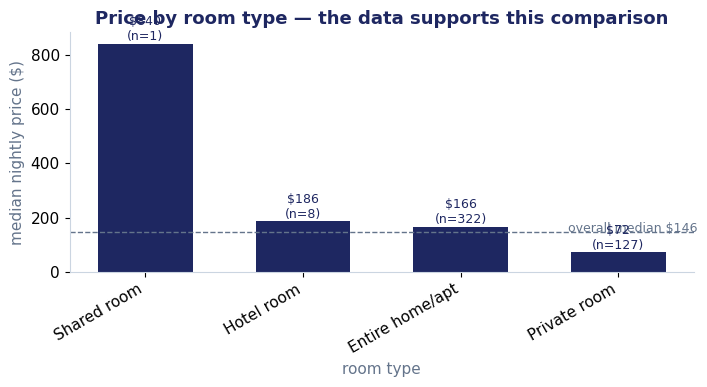

In [4]:
def price_bar(group_col, df=None, order=None, title="", xlabel="", color=NAVY, ax=None):
    d = (df if df is not None else listings).dropna(subset=["price_clean", group_col])
    n = d.groupby(group_col).size()
    r = d.groupby(group_col)["price_clean"].median()
    if order is not None:
        r, n = r.reindex(order), n.reindex(order)
    else:
        r = r.sort_values(ascending=False); n = n.reindex(r.index)
    if ax is None: fig, ax = plt.subplots()
    bars = ax.bar(r.index.astype(str), r.values, color=color, width=0.6)
    overall = d["price_clean"].median()
    ax.axhline(overall, color=SLATE, ls="--", lw=1)
    ax.text(len(r)-0.5, overall+3, f"overall median ${overall:.0f}", color=SLATE, ha="right", fontsize=9)
    for b, v, nn in zip(bars, r.values, n):
        ax.text(b.get_x()+b.get_width()/2, v+3, f"${v:.0f}\n(n={nn})",
                ha="center", va="bottom", fontsize=9, color=NAVY)
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel("median nightly price ($)")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    return ax

price_bar("room_type", title="Price by room type — the data supports this comparison", xlabel="room type", color=NAVY)
plt.tight_layout(); plt.show()

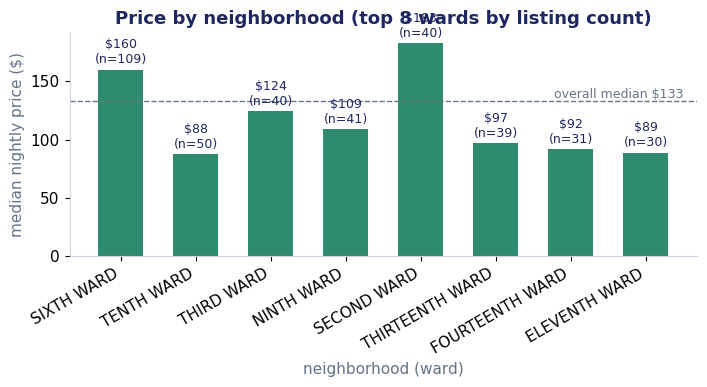

In [5]:
top8 = listings.neighbourhood_cleansed.value_counts().head(8).index.tolist()
price_bar("neighbourhood_cleansed", df=listings[listings.neighbourhood_cleansed.isin(top8)],
          order=top8, title="Price by neighborhood (top 8 wards by listing count)",
          xlabel="neighborhood (ward)", color=GREEN)
plt.tight_layout(); plt.show()

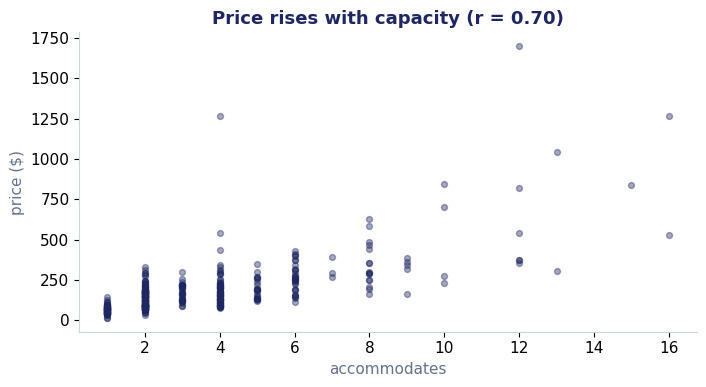

In [6]:
d = listings.dropna(subset=["price_clean", "accommodates"])
corr = d.price_clean.corr(d.accommodates)
fig, ax = plt.subplots()
ax.scatter(d.accommodates, d.price_clean, alpha=.4, color=NAVY, s=18)
ax.set_title(f"Price rises with capacity (r = {corr:.2f})")
ax.set_xlabel("accommodates"); ax.set_ylabel("price ($)")
plt.tight_layout(); plt.show()

These are **fit** wins: the data answers *"which features move the price?"* — room type, neighborhood,
and accommodates all show clean, sensible separation. Now the hard part.

## 3. Name the limits — with evidence
This is the real skill. Each limit below comes with evidence pulled straight from your own tables.

### Limit 1 — The target itself is incomplete, and 14 columns are dead on arrival.
`price` — the thing we're trying to predict — is missing for 32 of 490 listings (6.5%). Separately, 14
columns (`license`, `instant_bookable`, `host_since`, `host_response_rate`, `host_acceptance_rate`, ...) are
**100% empty**. That's not random noise — it's a scrape/export limitation of *this* extract, and it rules out
any feature (host responsiveness, licensing status) that isn't actually populated.

In [7]:
fully_empty = listings.columns[listings.isna().all()].tolist()
print(f"Columns that are 100% empty ({len(fully_empty)} of {listings.shape[1]}):")
for c in fully_empty: print(" -", c)
print(f"\nTarget (price) missing: {listings.price_clean.isna().sum()} / {len(listings)} listings "
      f"({listings.price_clean.isna().mean():.1%})")

Columns that are 100% empty (14 of 91):
 - neighborhood_overview
 - host_since
 - host_response_time
 - host_response_rate
 - host_acceptance_rate
 - host_thumbnail_url
 - host_neighbourhood
 - host_total_listings_count
 - host_verifications
 - neighbourhood
 - neighbourhood_group_cleansed
 - calendar_updated
 - license
 - instant_bookable

Target (price) missing: 32 / 490 listings (6.5%)


### Limit 2 — Price is a **host decision**, not a validated "right answer."
There's no `reason_this_price` column, and — more importantly — nothing here proves a listing's current
price is *good*. If high price barely relates to how often the place actually gets booked, that's a sign the
label we're trying to predict isn't itself a ground-truth optimum.

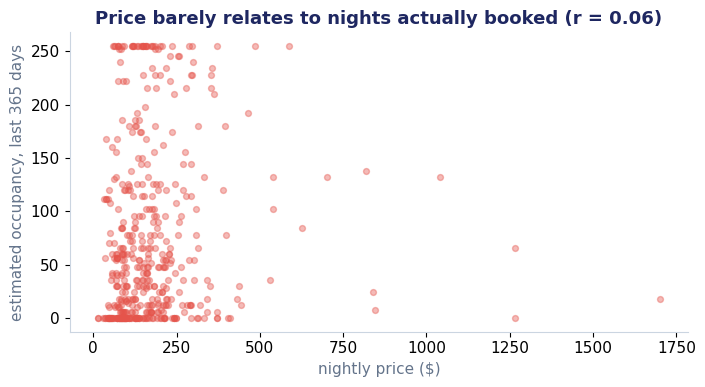

Correlation between price and estimated occupancy: r = 0.06 -- essentially no relationship.
=> A model that learns to reproduce today's prices is learning host habits, not proven demand.


In [8]:
d2 = listings.dropna(subset=["price_clean", "estimated_occupancy_l365d"])
corr_occ = d2.price_clean.corr(d2.estimated_occupancy_l365d)
fig, ax = plt.subplots()
ax.scatter(d2.price_clean, d2.estimated_occupancy_l365d, alpha=.4, color=CORAL, s=18)
ax.set_title(f"Price barely relates to nights actually booked (r = {corr_occ:.2f})")
ax.set_xlabel("nightly price ($)"); ax.set_ylabel("estimated occupancy, last 365 days")
plt.tight_layout(); plt.show()
print(f"Correlation between price and estimated occupancy: r = {corr_occ:.2f} -- essentially no relationship.")
print("=> A model that learns to reproduce today's prices is learning host habits, not proven demand.")

### Limit 3 — It's a **forward-looking snapshot, not a price history.**
`calendar.csv` only covers a ~1-year *future* availability window from the scrape date — it tells us nothing
about how price moved in the past, or how it responded to past demand. `reviews.csv` has history back to
2014, but that's guest activity, not price history. We have exactly one price observation per listing.

In [9]:
import pandas as pd

# Ensure calendar['date'] is datetime type
# This is necessary because calendar might have been reloaded from CSV without conversion in subsequent cells
if not pd.api.types.is_datetime64_any_dtype(calendar['date']):
    calendar['date'] = pd.to_datetime(calendar['date'])

# Ensure listings['first_review'] and listings['last_review'] are datetime type
# Convert with errors='coerce' to handle potential unparseable date strings by turning them into NaT
listings['first_review'] = pd.to_datetime(listings['first_review'], errors='coerce')
listings['last_review'] = pd.to_datetime(listings['last_review'], errors='coerce')

# Print calendar window
print("Calendar window:", calendar.date.min().date(), "to", calendar.date.max().date(),
      f"({(calendar.date.max()-calendar.date.min()).days} days, forward-looking only)")

# Print review history spans, handling potential NaT values from coerced conversions
first_review_min_date = listings.first_review.min()
last_review_max_date = listings.last_review.max()

print("Review history spans:",
      first_review_min_date.date() if pd.notna(first_review_min_date) else "N/A",
      "to",
      last_review_max_date.date() if pd.notna(last_review_max_date) else "N/A",
      "-- guest activity, NOT a price history")

print("Number of price observations per listing: 1 (current snapshot only)")

Calendar window: 2026-06-16 to 2027-06-21 (370 days, forward-looking only)
Review history spans: 2014-07-01 to 2026-06-16 -- guest activity, NOT a price history
Number of price observations per listing: 1 (current snapshot only)


### Limit 4 — **Correlation ≠ cause.** Neighborhood is tangled up with room type.
Some wards look expensive partly because they simply contain more entire-home listings (vs. private rooms).
Fixing room type and re-comparing neighborhoods shrinks — but doesn't erase — the gaps, which is the honest
middle ground: location matters, but not as cleanly as the raw chart implies.

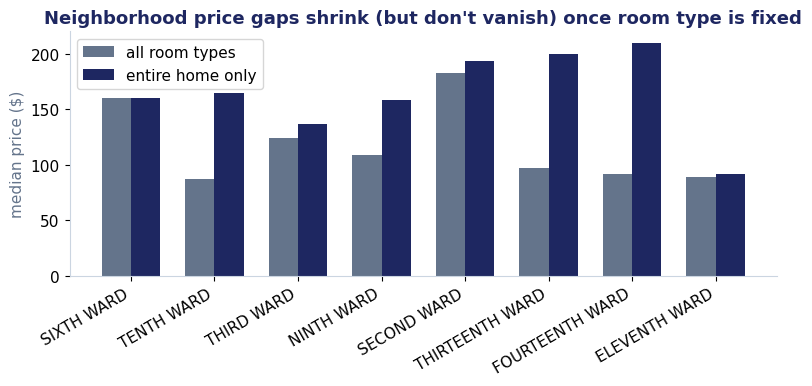

In [10]:
sub_all = listings[listings.neighbourhood_cleansed.isin(top8) & listings.price_clean.notna()]
med_all = sub_all.groupby("neighbourhood_cleansed").price_clean.median().reindex(top8)
sub_eh = sub_all[sub_all.room_type == "Entire home/apt"]
med_eh = sub_eh.groupby("neighbourhood_cleansed").price_clean.median().reindex(top8)

x = np.arange(len(top8)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, med_all.values, width=w, label="all room types", color=SLATE)
ax.bar(x + w/2, med_eh.values, width=w, label="entire home only", color=NAVY)
ax.set_xticks(x); ax.set_xticklabels(top8, rotation=30, ha="right")
ax.set_title("Neighborhood price gaps shrink (but don't vanish) once room type is fixed")
ax.set_ylabel("median price ($)"); ax.legend()
plt.tight_layout(); plt.show()

### Limit 5 — **Slice it and the cells get thin fast.**
Cross neighborhood with room type and several cells are tiny — Twelfth Ward has only 4 listings total, and
citywide there is exactly **one** shared room and **nine** hotel rooms (almost all in Third Ward). Any
"median price" built on a handful of listings has a wide error bar and shouldn't be trusted as a stable rate.

In [11]:
cnt = pd.crosstab(listings.neighbourhood_cleansed, listings.room_type)
print("Neighborhood x room type -- listing counts:")
print(cnt)
print("\nRoom type totals citywide:")
print(listings.room_type.value_counts())
print("\n=> Shared room (n=1) and Hotel room (n=9, mostly one neighborhood) are far too thin to price reliably.")

Neighborhood x room type -- listing counts:
room_type               Entire home/apt  Hotel room  Private room  Shared room
neighbourhood_cleansed                                                        
EIGHTH WARD                          11           0             2            0
ELEVENTH WARD                        23           1             8            0
FIFTEENTH WARD                       13           0             1            0
FIFTH WARD                           12           0             2            0
FIRST WARD                           12           0             0            0
FOURTEENTH WARD                      19           0            13            0
FOURTH WARD                          13           0             2            0
NINTH WARD                           20           0            21            1
SECOND WARD                          37           0             4            0
SEVENTH WARD                         12           0             2            0
SIXTH WA

### Limit 6 — **One city. Don't assume it generalizes.**
Every row is an Albany, NY listing scraped at one point in time. There's nothing in these four files that
proves the same feature-price relationships (e.g., the size premium, or the neighborhood ranking) hold in a
larger or seasonal tourist market. State it out loud — it's a **provenance** limit no chart can fix.

In [12]:
print("What we know about provenance FROM THE DATA ALONE:")
print("- Source system ................ Inside-Airbnb-style scrape (from URLs/scrape_id), not a host-verified feed")
print("- Time period covered .......... single scrape, 2026-06-16 / 2026-06-22 (two scrape dates only)")
print("- Geography ..................... one city (Albany, NY) -- 15 wards")
print("- Sampling ...................... whatever was publicly listed on Airbnb at scrape time; no non-Airbnb comps")
print("\n=> Generalizing to another city, platform, or season is an assumption, not a finding. Say so.")

What we know about provenance FROM THE DATA ALONE:
- Source system ................ Inside-Airbnb-style scrape (from URLs/scrape_id), not a host-verified feed
- Time period covered .......... single scrape, 2026-06-16 / 2026-06-22 (two scrape dates only)
- Geography ..................... one city (Albany, NY) -- 15 wards
- Sampling ...................... whatever was publicly listed on Airbnb at scrape time; no non-Airbnb comps

=> Generalizing to another city, platform, or season is an assumption, not a finding. Say so.


### Limit 7 — **Leakage watch.** Some "features" are built directly from price.
`estimated_revenue_l365d` isn't an independent signal — it's essentially `price x estimated_occupancy_l365d`.
Using it as a predictor would let the model "discover" the price it's supposed to be predicting. Separately,
60 listings (12%) have zero reviews, so any review-based feature (`review_scores_rating`,
`reviews_per_month`) is unavailable for exactly the newest listings that most need a pricing recommendation.

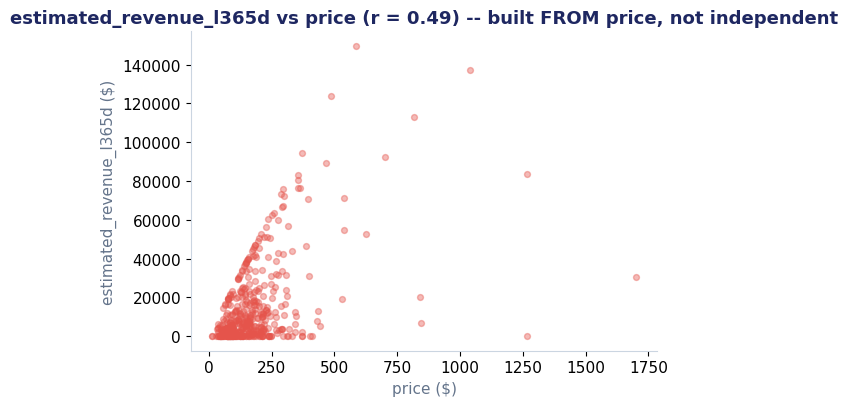

r = 0.4943 -- estimated_revenue_l365d is arithmetically derived from price. Drop it as a feature.

60 / 490 listings (12%) have zero reviews -- review-based features are missing exactly where a pricing model is needed most.


In [13]:
d3 = listings.dropna(subset=["price_clean", "estimated_occupancy_l365d", "estimated_revenue_l365d"])
corr_leak = d3.price_clean.corr(d3.estimated_revenue_l365d)
fig, ax = plt.subplots(figsize=(6, 4.2))
ax.scatter(d3.price_clean, d3.estimated_revenue_l365d, alpha=.4, color=CORAL, s=18)
ax.set_title(f"estimated_revenue_l365d vs price (r = {corr_leak:.2f}) -- built FROM price, not independent")
ax.set_xlabel("price ($)"); ax.set_ylabel("estimated_revenue_l365d ($)")
plt.tight_layout(); plt.show()

n_no_reviews = listings.number_of_reviews.eq(0).sum()
print(f"r = {corr_leak:.4f} -- estimated_revenue_l365d is arithmetically derived from price. Drop it as a feature.")
print(f"\n{n_no_reviews} / {len(listings)} listings ({n_no_reviews/len(listings):.0%}) have zero reviews "
      "-- review-based features are missing exactly where a pricing model is needed most.")

## 4. The one-slide takeaway
**What the Airbnb data earns us:** solid *what-moves-the-price* comparisons — room type, capacity, and
neighborhood all separate cleanly and defensibly.

**What it does not hand us, and we must say out loud:**
1. **Incomplete target & dead columns** — 6.5% of listings have no price; 14 columns are 100% empty.
2. **Price isn't validated demand** — price barely correlates with actual bookings (r ~ 0.06), so we're modeling host habit, not a proven optimum.
3. **Snapshot, not a price history** — one observation per listing; the calendar only looks forward.
4. **Correlation ≠ cause** — neighborhood premiums are partly just room-type composition.
5. **Thin cells** — shared rooms (n=1) and hotel rooms (n=9) can't support a reliable price estimate.
6. **One city** — Albany-only; generalization is an assumption, not a finding.
7. **Leakage risk** — `estimated_revenue_l365d` is built from price; review features are missing for the newest 12% of listings.

> Good data won't make a good project -- but naming these limits *before* someone else does is exactly what
> makes the rest of the pricing analysis credible.

---
# Week 3 — First Cleaning Pass & Exploratory Pricing Questions

This section loads and cleans the data independently (its own Drive mount + `df_available`), as it did originally — a few weeks before the pipeline below was finalized.

In [16]:
import pandas as pd
import numpy as np
import ast

listings = pd.read_csv("C:\\Users\\valla\\Downloads\\listings (1).csv")
calendar = pd.read_csv("C:\\Users\\valla\\Downloads\\calendar.csv")
reviews  = pd.read_csv("C:\\Users\\valla\\Downloads\\reviews.csv")

print(listings.shape, calendar.shape, reviews.shape)
required_features = [
  'price', 'beds', 'accommodates', 'bedrooms', 'bathrooms', 'amenities_count',
    'room_type', 'property_type', 'neighbourhood_cleansed', 'minimum_nights'
]

available_now = [c for c in required_features if c in listings.columns]
missing_now = [c for c in required_features if c not in listings.columns]

print("Columns available directly from raw file:", available_now)
print("Columns not yet created (need feature engineering):", missing_now)

df_raw = listings.reindex(columns=required_features)

print(f"\nShape: {df_raw.shape}")
df_raw

(490, 90) (178850, 5) (29046, 6)
Columns available directly from raw file: ['price', 'beds', 'accommodates', 'bedrooms', 'bathrooms', 'room_type', 'property_type', 'neighbourhood_cleansed', 'minimum_nights']
Columns not yet created (need feature engineering): ['amenities_count']

Shape: (490, 10)


,price,beds,accommodates,bedrooms,bathrooms,amenities_count,room_type,property_type,neighbourhood_cleansed,minimum_nights
0,$80.43,2.0,4,2.0,1.0,NaN,Entire home/apt,Entire rental unit,THIRD WARD,28.0
1,$211.00,1.0,3,1.0,1.0,NaN,Entire home/apt,Entire rental unit,SIXTH WARD,1.0
2,$97.00,1.0,2,NaN,1.0,NaN,Entire home/apt,Entire rental unit,SECOND WARD,1.0
3,$160.00,1.0,2,1.0,1.0,NaN,Entire home/apt,Entire rental unit,SIXTH WARD,1.0
4,$86.00,2.0,2,NaN,1.0,NaN,Private room,Private room in rental unit,SECOND WARD,1.0
...,...,...,...,...,...,...,...,...,...,...
485,$149.00,2.0,4,1.0,1.0,NaN,Entire home/apt,Entire rental unit,TENTH WARD,1.0
486,$213.00,1.0,2,1.0,1.0,NaN,Entire home/apt,Entire rental unit,SIXTH WARD,1.0
487,$114.50,1.0,1,1.0,2.0,NaN,Private room,Private room in rental unit,SIXTH WARD,2.0
488,$86.00,1.0,1,2.0,2.0,NaN,Private room,Private room in rental unit,SIXTH WARD,2.0


Slicing data

In [17]:
available_now = [c for c in required_features if c in listings.columns]
missing_now   = [c for c in required_features if c not in listings.columns]

print("Available (sliced from listings.csv):", available_now)
print("Missing (need feature engineering):", missing_now)


df_available = listings[available_now]

print(f"\nShape: {df_available.shape}")
df_available

Available (sliced from listings.csv): ['price', 'beds', 'accommodates', 'bedrooms', 'bathrooms', 'room_type', 'property_type', 'neighbourhood_cleansed', 'minimum_nights']
Missing (need feature engineering): ['amenities_count']

Shape: (490, 9)


,price,beds,accommodates,bedrooms,bathrooms,room_type,property_type,neighbourhood_cleansed,minimum_nights
0,$80.43,2.0,4,2.0,1.0,Entire home/apt,Entire rental unit,THIRD WARD,28.0
1,$211.00,1.0,3,1.0,1.0,Entire home/apt,Entire rental unit,SIXTH WARD,1.0
2,$97.00,1.0,2,NaN,1.0,Entire home/apt,Entire rental unit,SECOND WARD,1.0
3,$160.00,1.0,2,1.0,1.0,Entire home/apt,Entire rental unit,SIXTH WARD,1.0
4,$86.00,2.0,2,NaN,1.0,Private room,Private room in rental unit,SECOND WARD,1.0
...,...,...,...,...,...,...,...,...,...
485,$149.00,2.0,4,1.0,1.0,Entire home/apt,Entire rental unit,TENTH WARD,1.0
486,$213.00,1.0,2,1.0,1.0,Entire home/apt,Entire rental unit,SIXTH WARD,1.0
487,$114.50,1.0,1,1.0,2.0,Private room,Private room in rental unit,SIXTH WARD,2.0
488,$86.00,1.0,1,2.0,2.0,Private room,Private room in rental unit,SIXTH WARD,2.0


Cleaning and adding amenities count

In [18]:
def count_amenities(x):
    try:
        lst = ast.literal_eval(x)
        return len(lst)
    except (ValueError, SyntaxError, TypeError):
        if isinstance(x, str):
            return len(x.split(','))
        return 0

listings['amenities_count'] = listings['amenities'].apply(count_amenities)

df_available['amenities_count'] = listings['amenities_count']

print(f"Shape: {df_available.shape}")
df_available.head()

Shape: (490, 10)


C:\Users\valla\AppData\Local\Temp\ipykernel_6436\1382773446.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_available['amenities_count'] = listings['amenities_count']


,price,beds,accommodates,bedrooms,bathrooms,room_type,property_type,neighbourhood_cleansed,minimum_nights,amenities_count
0,$80.43,2.0,4,2.0,1.0,Entire home/apt,Entire rental unit,THIRD WARD,28.0,8
1,$211.00,1.0,3,1.0,1.0,Entire home/apt,Entire rental unit,SIXTH WARD,1.0,32
2,$97.00,1.0,2,NaN,1.0,Entire home/apt,Entire rental unit,SECOND WARD,1.0,40
3,$160.00,1.0,2,1.0,1.0,Entire home/apt,Entire rental unit,SIXTH WARD,1.0,43
4,$86.00,2.0,2,NaN,1.0,Private room,Private room in rental unit,SECOND WARD,1.0,28


Cleaning bathrooms coloum and price

In [19]:
print(listings[['bathrooms']].isna().sum() if 'bathrooms' in listings.columns else "no bathrooms col")
print(listings[['bathrooms_text']].head(10) if 'bathrooms_text' in listings.columns else "no bathrooms_text col")

listings['bathrooms'] = listings['bathrooms'].fillna(
    listings['bathrooms_text'].str.extract(r'(\d+\.?\d*)').astype(float)[0]
)

print("NaNs in bathrooms after fill:", listings['bathrooms'].isna().sum())



df_available = df_available.copy()

df_available['price'] = (
    df_available['price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

print(df_available['price'].describe())
df_available['price'] = df_available['price'].fillna(df_available['price'].median())
print("NaNs in price:", df_available['price'].isna().sum())


bathrooms    45
dtype: int64
     bathrooms_text
0            1 bath
1            1 bath
2            1 bath
3            1 bath
4    1 private bath
5    1 private bath
6           2 baths
7  1.5 shared baths
8     1 shared bath
9           2 baths
NaNs in bathrooms after fill: 0
count     458.000000
mean      177.127293
std       157.348920
min        13.180000
25%        90.000000
50%       145.665000
75%       209.625000
max      1701.000000
Name: price, dtype: float64
NaNs in price: 0


checking availability of all remaining coloumns

In [20]:
new_features = ['beds', 'accommodates', 'bedrooms', 'room_type',
                 'property_type', 'neighbourhood_cleansed',
                 'minimum_nights', 'amenities_count']

available_now2 = [c for c in new_features if c in listings.columns]
missing_now2   = [c for c in new_features if c not in listings.columns]

print("Available (sliced from listings.csv):", available_now2)
print("Missing (need feature engineering):", missing_now2)

Available (sliced from listings.csv): ['beds', 'accommodates', 'bedrooms', 'room_type', 'property_type', 'neighbourhood_cleansed', 'minimum_nights', 'amenities_count']
Missing (need feature engineering): []


adding data for aminities_count if missing

In [21]:
if 'amenities_count' in missing_now2:
    import ast
    def count_amenities(x):
        try:
            return len(ast.literal_eval(x))
        except (ValueError, SyntaxError, TypeError):
            return 0
    listings['amenities_count'] = listings['amenities'].apply(count_amenities)
    print("amenities_count engineered. NaNs:", listings['amenities_count'].isna().sum())

adding median data for remaining coloumns

In [22]:
print("NaNs before fill:")
for col in ['beds', 'bedrooms']:
    print(f"  {col}: {listings[col].isna().sum()}")

listings['beds'] = listings['beds'].fillna(
    listings.groupby('accommodates')['beds'].transform('median')
)
listings['beds'] = listings['beds'].fillna(listings['beds'].median())

listings['bedrooms'] = listings['bedrooms'].fillna(
    listings.groupby('accommodates')['bedrooms'].transform('median')
)
listings['bedrooms'] = listings['bedrooms'].fillna(listings['bedrooms'].median())

print("NaNs after fill:")
for col in ['beds', 'bedrooms']:
    print(f"  {col}: {listings[col].isna().sum()}")

NaNs before fill:
  beds: 44
  bedrooms: 112
NaNs after fill:
  beds: 0
  bedrooms: 0


In [23]:
print(df_available[df_available['minimum_nights'].isna()])

df_available['minimum_nights'] = df_available['minimum_nights'].fillna(
    df_available['minimum_nights'].median()
)

print("minimum_nights NaNs after fill:", df_available['minimum_nights'].isna().sum())

      price  beds  accommodates  bedrooms  bathrooms        room_type  \
58  145.665   NaN             6       3.0        NaN  Entire home/apt   

   property_type neighbourhood_cleansed  minimum_nights  amenities_count  
58   Entire home             TENTH WARD             NaN               52  
minimum_nights NaNs after fill: 0


In [24]:
all_needed = list(set(available_now2 + ['amenities_count']))

for col in all_needed:
    df_available[col] = listings.loc[df_available.index, col]

print(f"\nShape: {df_available.shape}")
df_available.head()


Shape: (490, 10)


,price,beds,accommodates,bedrooms,bathrooms,room_type,property_type,neighbourhood_cleansed,minimum_nights,amenities_count
0,80.43,2.0,4,2.0,1.0,Entire home/apt,Entire rental unit,THIRD WARD,28.0,8
1,211.00,1.0,3,1.0,1.0,Entire home/apt,Entire rental unit,SIXTH WARD,1.0,32
2,97.00,1.0,2,1.0,1.0,Entire home/apt,Entire rental unit,SECOND WARD,1.0,40
3,160.00,1.0,2,1.0,1.0,Entire home/apt,Entire rental unit,SIXTH WARD,1.0,43
4,86.00,2.0,2,1.0,1.0,Private room,Private room in rental unit,SECOND WARD,1.0,28


In [25]:
# --- fix bathrooms: re-sync the already-filled column from listings ---
print("bathrooms NaNs in listings:", listings['bathrooms'].isna().sum())  # should be 0

df_available['bathrooms'] = listings.loc[df_available.index, 'bathrooms']

print("bathrooms NaNs in df_available after sync:", df_available['bathrooms'].isna().sum())

bathrooms NaNs in listings: 0
bathrooms NaNs in df_available after sync: 0


checking for duplicates and nulls

In [26]:
print("Duplicate rows:", df_available.duplicated().sum())

if 'id' in df_available.columns:
    print("Duplicate ids:", df_available['id'].duplicated().sum())

before = df_available.shape[0]
df_available = df_available.drop_duplicates()
after = df_available.shape[0]

print(f"Removed {before - after} duplicate rows")
print(f"Shape after dedup: {df_available.shape}")


null_counts = df_available.isna().sum()
print(null_counts)

print("\nTotal NaNs remaining:", null_counts.sum())
print("Fully null-free:", null_counts.sum() == 0)

Duplicate rows: 9
Removed 9 duplicate rows
Shape after dedup: (481, 10)
price                     0
beds                      0
accommodates              0
bedrooms                  0
bathrooms                 0
room_type                 0
property_type             0
neighbourhood_cleansed    0
minimum_nights            1
amenities_count           0
dtype: int64

Total NaNs remaining: 1
Fully null-free: False


In [27]:
df_available

,price,beds,accommodates,bedrooms,bathrooms,room_type,property_type,neighbourhood_cleansed,minimum_nights,amenities_count
0,80.43,2.0,4,2.0,1.0,Entire home/apt,Entire rental unit,THIRD WARD,28.0,8
1,211.00,1.0,3,1.0,1.0,Entire home/apt,Entire rental unit,SIXTH WARD,1.0,32
2,97.00,1.0,2,1.0,1.0,Entire home/apt,Entire rental unit,SECOND WARD,1.0,40
3,160.00,1.0,2,1.0,1.0,Entire home/apt,Entire rental unit,SIXTH WARD,1.0,43
4,86.00,2.0,2,1.0,1.0,Private room,Private room in rental unit,SECOND WARD,1.0,28
...,...,...,...,...,...,...,...,...,...,...
485,149.00,2.0,4,1.0,1.0,Entire home/apt,Entire rental unit,TENTH WARD,1.0,26
486,213.00,1.0,2,1.0,1.0,Entire home/apt,Entire rental unit,SIXTH WARD,1.0,7
487,114.50,1.0,1,1.0,2.0,Private room,Private room in rental unit,SIXTH WARD,2.0,5
488,86.00,1.0,1,2.0,2.0,Private room,Private room in rental unit,SIXTH WARD,2.0,7


1. Which neighborhoods should be prioritized for a pricing review, based on how far below the city average they fall?

In [28]:
import matplotlib.pyplot as plt

# --- compute average price + listing count per neighborhood ---
neighborhood_stats = df_available.groupby('neighbourhood_cleansed')['price'].agg(['mean', 'count']).round(2)
neighborhood_stats.columns = ['avg_price', 'listing_count']

# --- filter out neighborhoods with too few listings (unstable average) ---
MIN_LISTINGS = 3
neighborhood_stats = neighborhood_stats[neighborhood_stats['listing_count'] >= MIN_LISTINGS]

# --- overall city-wide average price (benchmark) ---
city_avg = df_available['price'].mean()

# --- build comparison table ---
compare_df = neighborhood_stats.reset_index()
compare_df.columns = ['neighbourhood', 'avg_price', 'listing_count']
compare_df['city_avg'] = city_avg
compare_df['diff'] = compare_df['avg_price'] - compare_df['city_avg']

# sort ascending: most underpriced (most negative diff) first
compare_df = compare_df.sort_values('diff')

# take top 6 most underpriced (matches the reference chart's format)
top_n = compare_df.head(6).sort_values('avg_price')  # sort ascending for horizontal bar order



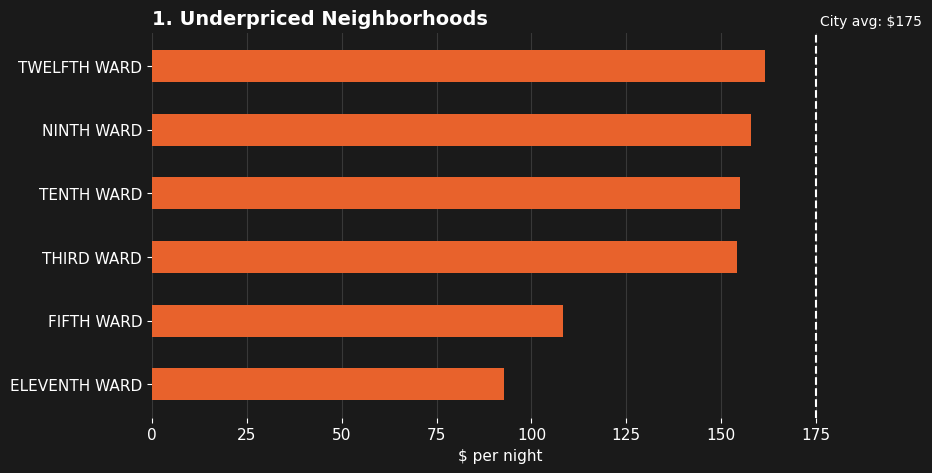

In [29]:
fig, ax = plt.subplots(figsize=(9, 5), facecolor='#1a1a1a')
ax.set_facecolor('#1a1a1a')

y_pos = range(len(top_n))
colors = ['#e8622c' if v < city_avg else '#b5b0a8' for v in top_n['avg_price']]

ax.barh(y_pos, top_n['avg_price'], color=colors, height=0.5)
ax.axvline(city_avg, color='white', linestyle='--', linewidth=1.5)
ax.text(city_avg + 1, len(top_n) - 0.3, f'City avg: ${city_avg:.0f}',
        color='white', fontsize=10, va='center')

ax.set_yticks(list(y_pos))
ax.set_yticklabels(top_n['neighbourhood'], color='white')
ax.set_xlabel('$ per night', color='white')
ax.tick_params(colors='white')
ax.set_title('1. Underpriced Neighborhoods', color='white', fontsize=14, loc='left', fontweight='bold')

for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(axis='x', color='gray', alpha=0.3)
ax.set_axisbelow(True)

# plt.tight_layout()
plt.show()

2. Is requiring a longer minimum stay costing hosts revenue per night — and what's the shortest they can safely go?

min_nights_bucket
1 night        202.775237
2-3 nights     185.757477
4-7 nights     140.196875
8-29 nights     90.511354
30+ nights      93.070758
Name: price, dtype: float64


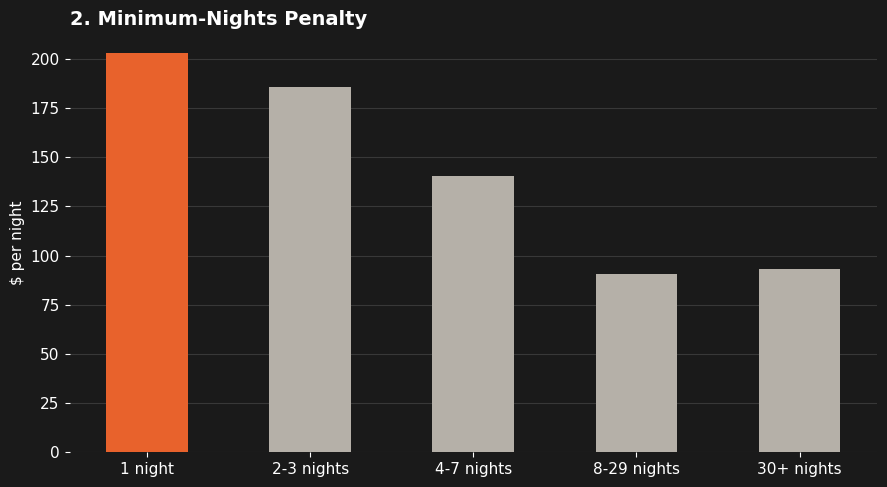

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

# --- bin minimum_nights into categories ---
def bucket_nights(n):
    if n == 1:
        return '1 night'
    elif 2 <= n <= 3:
        return '2-3 nights'
    elif 4 <= n <= 7:
        return '4-7 nights'
    elif 8 <= n <= 29:
        return '8-29 nights'
    else:
        return '30+ nights'

df_available['min_nights_bucket'] = df_available['minimum_nights'].apply(bucket_nights)

# preserve logical order (not alphabetical)
bucket_order = ['1 night', '2-3 nights', '4-7 nights', '8-29 nights', '30+ nights']
df_available['min_nights_bucket'] = pd.Categorical(
    df_available['min_nights_bucket'], categories=bucket_order, ordered=True
)

# --- avg price per bucket ---
bucket_avg = df_available.groupby('min_nights_bucket', observed=True)['price'].mean().reindex(bucket_order)

print(bucket_avg)

# --- plot ---
fig, ax = plt.subplots(figsize=(9, 5), facecolor='#1a1a1a')
ax.set_facecolor('#1a1a1a')

# highlight the bucket with the highest avg price
max_bucket = bucket_avg.idxmax()
colors = ['#e8622c' if b == max_bucket else '#b5b0a8' for b in bucket_avg.index]

ax.bar(bucket_avg.index, bucket_avg.values, color=colors, width=0.5)

ax.set_ylabel('$ per night', color='white')
ax.tick_params(colors='white')
ax.set_title('2. Minimum-Nights Penalty', color='white', fontsize=14, loc='left', fontweight='bold')

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(axis='y', color='gray', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

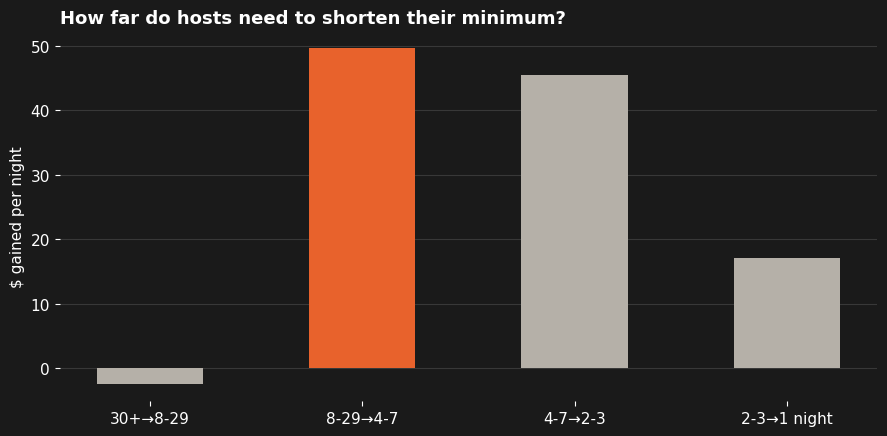

In [32]:
# reverse order: longest to shortest, so we read it as "shortening the minimum"
reversed_order = bucket_avg.reindex(bucket_order[::-1])
gains = reversed_order.diff().dropna()
step_labels = ['30+→8-29', '8-29→4-7', '4-7→2-3', '2-3→1 night']

fig, ax = plt.subplots(figsize=(9, 4.5), facecolor='#1a1a1a')
ax.set_facecolor('#1a1a1a')
colors = ['#e8622c' if v == gains.max() else '#b5b0a8' for v in gains.values]
ax.bar(step_labels, gains.values, color=colors, width=0.5)
ax.set_ylabel('$ gained per night', color='white')
ax.tick_params(colors='white')
ax.set_title('How far do hosts need to shorten their minimum?', color='white', fontsize=13, loc='left', fontweight='bold')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(axis='y', color='gray', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

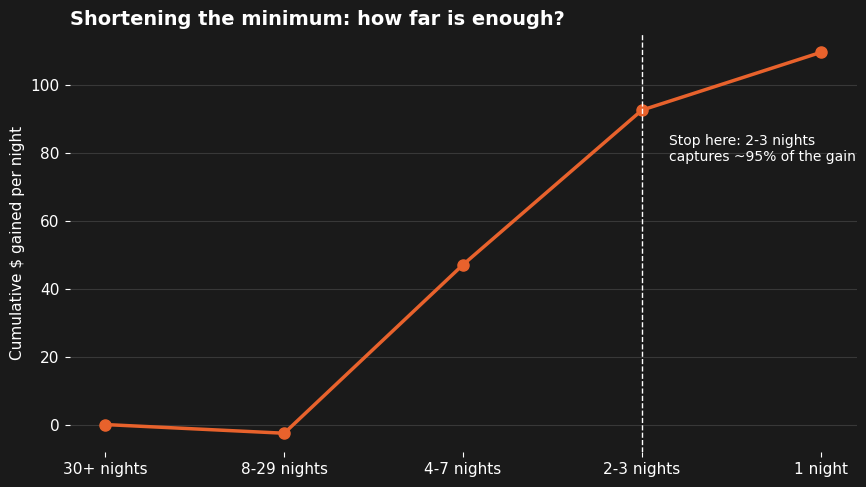

In [33]:
reversed_order = bucket_avg.reindex(bucket_order[::-1])
cum_gain = (reversed_order - reversed_order.iloc[0])  # cumulative $ recovered vs. staying at 30+

fig, ax = plt.subplots(figsize=(9, 5), facecolor='#1a1a1a')
ax.set_facecolor('#1a1a1a')
ax.plot(cum_gain.index.astype(str), cum_gain.values, color='#e8622c', marker='o', linewidth=2.5, markersize=8)

# mark the recommended stopping point
stop_idx = list(cum_gain.index).index('2-3 nights')
ax.axvline(stop_idx, color='white', linestyle='--', linewidth=1)
ax.annotate('Stop here: 2-3 nights\ncaptures ~95% of the gain',
            xy=(stop_idx, cum_gain['2-3 nights']), xytext=(stop_idx+0.15, cum_gain['2-3 nights']-15),
            color='white', fontsize=10)

ax.set_ylabel('Cumulative $ gained per night', color='white')
ax.tick_params(colors='white')
ax.set_title('Shortening the minimum: how far is enough?', color='white', fontsize=14, loc='left', fontweight='bold')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(axis='y', color='gray', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

3. Does each additional bedroom add the same amount to price, or less each time?

bedrooms
1.0     127.933328
2.0     192.173144
3.0     244.026023
4.0     399.066304
5.0     478.297143
6.0    1040.500000
7.0     840.000000
8.0      66.115000
9.0    1265.000000
Name: price, dtype: float64
{'1 to 2 BR': 64.23981646104444, '2 to 3 BR': 51.85287839737583, '3 to 4 BR': 155.04028162055334, '4 to 5 BR': 79.23083850931675}


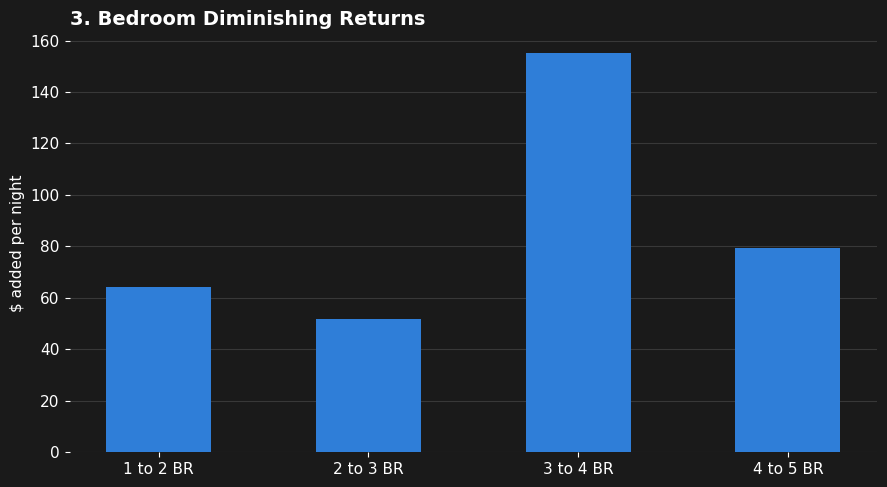

In [34]:
import matplotlib.pyplot as plt

# --- avg price per bedroom count ---
bedroom_avg = df_available.groupby('bedrooms')['price'].mean()

print(bedroom_avg)

# --- compute marginal $ added per additional bedroom (1→2, 2→3, 3→4, 4→5) ---
transitions = [(1, 2), (2, 3), (3, 4), (4, 5)]
labels = []
deltas = []

for low, high in transitions:
    if low in bedroom_avg.index and high in bedroom_avg.index:
        delta = bedroom_avg[high] - bedroom_avg[low]
        labels.append(f'{low} to {high} BR')
        deltas.append(delta)

print(dict(zip(labels, deltas)))

# --- plot ---
fig, ax = plt.subplots(figsize=(9, 5), facecolor='#1a1a1a')
ax.set_facecolor('#1a1a1a')

ax.bar(labels, deltas, color='#2f7ed8', width=0.5)

ax.set_ylabel('$ added per night', color='white')
ax.tick_params(colors='white')
ax.set_title('3. Bedroom Diminishing Returns', color='white', fontsize=14, loc='left', fontweight='bold')

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(axis='y', color='gray', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

---
# Week 4 — Final Cleaning, Correlation Analysis & Model Comparison

This is the canonical cleaning + modeling pipeline the rest of the project (Weeks 5 and 6) builds on.

In [35]:
import pandas as pd
import numpy as np
import ast

listings = pd.read_csv("C:\\Users\\valla\\Downloads\\listings (1).csv")

print(listings.shape)

required_features = [
    'price', 'beds', 'accommodates', 'bedrooms', 'bathrooms', 'amenities_count',
    'room_type', 'property_type', 'neighbourhood_cleansed', 'minimum_nights'
]

(490, 90)


adding aminities count

In [37]:

def count_amenities(x):
    try:
        return len(ast.literal_eval(x))
    except (ValueError, SyntaxError, TypeError):
        if isinstance(x, str):
            return len(x.split(','))
        return 0

listings['amenities_count'] = listings['amenities'].apply(count_amenities)

cleaning bathroom feature

In [38]:
print("bathrooms NaNs before:", listings['bathrooms'].isna().sum())

listings['bathrooms'] = listings['bathrooms'].fillna(
    listings['bathrooms_text'].str.extract(r'(\d+\.?\d*)').astype(float)[0]
)

print("bathrooms NaNs after:", listings['bathrooms'].isna().sum())

bathrooms NaNs before: 45
bathrooms NaNs after: 0


cleaning beds & bedrooms

In [39]:
print("NaNs before fill:")
for col in ['beds', 'bedrooms']:
    print(f"  {col}: {listings[col].isna().sum()}")

listings['beds'] = listings['beds'].fillna(
    listings.groupby('accommodates')['beds'].transform('median')
)
listings['beds'] = listings['beds'].fillna(listings['beds'].median())

listings['bedrooms'] = listings['bedrooms'].fillna(
    listings.groupby('accommodates')['bedrooms'].transform('median')
)
listings['bedrooms'] = listings['bedrooms'].fillna(listings['bedrooms'].median())

print("NaNs after fill:")
for col in ['beds', 'bedrooms']:
    print(f"  {col}: {listings[col].isna().sum()}")

NaNs before fill:
  beds: 44
  bedrooms: 112
NaNs after fill:
  beds: 0
  bedrooms: 0


Cleaning minimum nights

In [40]:
listings['minimum_nights'] = listings['minimum_nights'].fillna(
    listings['minimum_nights'].median()
)
print("minimum_nights NaNs after fill:", listings['minimum_nights'].isna().sum())

minimum_nights NaNs after fill: 0


cleaning price column

In [41]:
df_available = listings[required_features].copy()

df_available['price'] = (
    df_available['price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

print(df_available['price'].describe())
print("Price NaNs:", df_available['price'].isna().sum())

df_available = df_available.dropna(subset=['price'])
print("Shape after dropping missing price:", df_available.shape)

count     458.000000
mean      177.127293
std       157.348920
min        13.180000
25%        90.000000
50%       145.665000
75%       209.625000
max      1701.000000
Name: price, dtype: float64
Price NaNs: 32
Shape after dropping missing price: (458, 10)


Checking nulls

In [42]:

print("Duplicate rows:", df_available.duplicated().sum())
df_available = df_available.drop_duplicates()

null_counts = df_available.isna().sum()
print(null_counts)
print("\nTotal NaNs remaining:", null_counts.sum())
print("Fully null-free:", null_counts.sum() == 0)

Duplicate rows: 9
price                     0
beds                      0
accommodates              0
bedrooms                  0
bathrooms                 0
amenities_count           0
room_type                 0
property_type             0
neighbourhood_cleansed    0
minimum_nights            0
dtype: int64

Total NaNs remaining: 0
Fully null-free: True


Feature target correlation

In [43]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_corr = df_available.copy()
df_corr['log_price'] = np.log(df_corr['price'])

num_features = ['beds', 'accommodates', 'bedrooms', 'bathrooms', 'amenities_count', 'minimum_nights']

corr_with_price = df_corr[num_features + ['price', 'log_price']].corr()[['price', 'log_price']].drop(['price', 'log_price'])
print("Correlation with target:")
print(corr_with_price.sort_values('log_price', ascending=False))

Correlation with target:
                    price  log_price
accommodates     0.707116   0.708448
beds             0.627225   0.590568
bedrooms         0.585412   0.524487
bathrooms        0.487034   0.322061
amenities_count  0.340021   0.320913
minimum_nights  -0.256655  -0.499601


Multicollinearity checking

In [44]:
X_vif = df_corr[num_features].copy()
X_vif = X_vif.dropna()
X_vif = sm.add_constant(X_vif) if 'sm' in dir() else __import__('statsmodels.api', fromlist=['add_constant']).add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)

           feature        VIF
0            const  10.098641
1             beds   4.723560
2     accommodates   4.747600
3         bedrooms   3.069230
4        bathrooms   1.510043
5  amenities_count   1.169525
6   minimum_nights   1.082793


correlation ratio (eta) with log_price

In [45]:
def correlation_ratio(categories, values):
    categories = pd.Series(categories)
    values = pd.Series(values)
    ss_total = np.sum((values - values.mean())**2)
    ss_between = categories.groupby(categories).apply(
        lambda g: len(g) * (values[g.index].mean() - values.mean())**2
    ).sum()
    return np.sqrt(ss_between / ss_total)

cat_features = ['room_type', 'property_type', 'neighbourhood_cleansed']
for col in cat_features:
    eta = correlation_ratio(df_corr[col], df_corr['log_price'])
    print(f"{col}: correlation ratio (eta) = {eta:.3f}")

room_type: correlation ratio (eta) = 0.594
property_type: correlation ratio (eta) = 0.754
neighbourhood_cleansed: correlation ratio (eta) = 0.412


# Data characterstics

Targer variable behaviour

In [46]:
print(df_available['price'].describe())
print("Skew:", df_available['price'].skew())
print("Skew (log):", np.log(df_available['price']).skew())

count     449.000000
mean      177.150690
std       158.391753
min        13.180000
25%        90.000000
50%       145.330000
75%       208.500000
max      1701.000000
Name: price, dtype: float64
Skew: 4.60020654464266
Skew (log): 0.18546797479858484


# Sample size vs feature complexity

In [47]:
print(df_available.shape)
for col in ['room_type', 'property_type', 'neighbourhood_cleansed']:
    print(col, "unique values:", df_available[col].nunique())

(449, 10)
room_type unique values: 4
property_type unique values: 21
neighbourhood_cleansed unique values: 15


# Linearity check

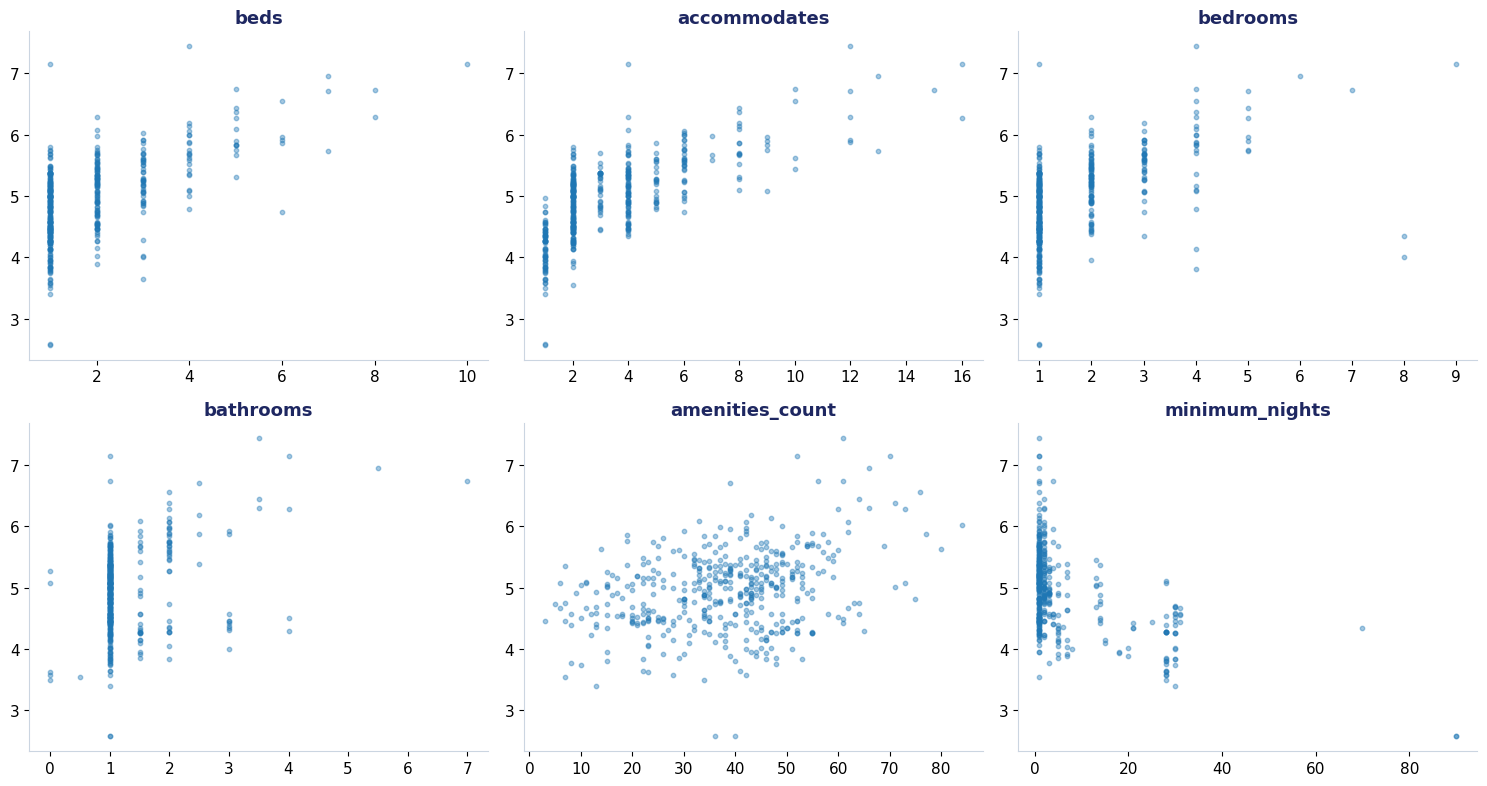

In [48]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 3, figsize=(15,8))
for ax, col in zip(axes.flat, num_features):
    ax.scatter(df_corr[col], df_corr['log_price'], alpha=0.4, s=10)
    ax.set_title(col)
plt.tight_layout()

In [49]:
df_available[num_features].describe(percentiles=[.01,.05,.95,.99])

,beds,accommodates,bedrooms,bathrooms,amenities_count,minimum_nights
count,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000
mean,1.832962,3.347439,1.639198,1.223831,38.209354,5.596882
std,1.316509,2.474783,1.141301,0.643919,14.490477,10.650708
min,1.000000,1.000000,1.000000,0.000000,3.000000,1.000000
1%,1.000000,1.000000,1.000000,0.240000,7.000000,1.000000
5%,1.000000,1.000000,1.000000,1.000000,13.000000,1.000000
50%,1.000000,2.000000,1.000000,1.000000,39.000000,1.000000
95%,4.600000,8.000000,4.000000,2.300000,61.000000,30.000000
99%,7.000000,12.520000,5.520000,4.000000,74.040000,31.000000
max,10.000000,16.000000,9.000000,7.000000,84.000000,90.000000


# Modeling

In [50]:
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df_model = df_available.copy()
df_model['log_price'] = np.log(df_model['price'])

X = df_model[num_features + cat_features]
y = df_model['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (359, 9) Test shape: (90, 9)


Preprocessing: scale numeric features, one-hot low-cardinality categoricals, and group rare categories for high-cardinality ones (property_type has 21 levels vs only ~449 rows, so raw one-hot risks overfitting).

In [51]:
low_card_cat = ['room_type']
high_card_cat = ['property_type', 'neighbourhood_cleansed']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('low_card', OneHotEncoder(handle_unknown='ignore'), low_card_cat),
    ('high_card', OneHotEncoder(handle_unknown='ignore', min_frequency=10, max_categories=10), high_card_cat)
])


Candidate models: Lasso (regularized linear — best fit given the clean linear correlations and low VIF from your EDA) plus RandomForest and GradientBoosting (to capture any nonlinearity/interactions).

In [52]:
models = {
    'Lasso': LassoCV(alphas=np.logspace(-3, 1, 50), max_iter=10000, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=3, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                                                   subsample=0.8, random_state=42)
}


5-fold cross-validation on the training set (small n = 449, so a single train/test split alone would be too noisy to trust for model comparison).

In [53]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = []
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    cv_res = cross_validate(
        pipe, X_train, y_train, cv=kf,
        scoring={'rmse_log': 'neg_root_mean_squared_error', 'mae_log': 'neg_mean_absolute_error', 'r2': 'r2'}
    )
    results.append({
        'model': name,
        'cv_rmse_log': -cv_res['test_rmse_log'].mean(),
        'cv_mae_log': -cv_res['test_mae_log'].mean(),
        'cv_r2': cv_res['test_r2'].mean()
    })

results_df = pd.DataFrame(results).sort_values('cv_rmse_log').reset_index(drop=True)
print(results_df)


              model  cv_rmse_log  cv_mae_log     cv_r2
0             Lasso     0.330169    0.256215  0.717900
1      RandomForest     0.333784    0.244255  0.712649
2  GradientBoosting     0.337975    0.237342  0.705177


Fold-to-fold stability: instead of just the average CV RMSE, look at how much RMSE varies across the 5 folds. A model with a similar average but lower variance is more trustworthy - it isn't getting lucky on some splits and unlucky on others.

In [54]:
stability_rows = []
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    fold_scores = cross_validate(
        pipe, X_train, y_train, cv=kf,
        scoring={'rmse_log': 'neg_root_mean_squared_error'}
    )
    fold_rmses = -fold_scores['test_rmse_log']  # one RMSE per fold
    stability_rows.append({
        'model': name,
        'fold_rmse_values': np.round(fold_rmses, 4),
        'mean_rmse': fold_rmses.mean(),
        'std_rmse': fold_rmses.std(),
        'min_rmse': fold_rmses.min(),
        'max_rmse': fold_rmses.max(),
        'range_rmse': fold_rmses.max() - fold_rmses.min()
    })

stability_df = pd.DataFrame(stability_rows).sort_values('std_rmse').reset_index(drop=True)
pd.set_option('display.width', 120)
print(stability_df[['model', 'mean_rmse', 'std_rmse', 'range_rmse']])
print()
for row in stability_rows:
    print(f"{row['model']:>18}: {row['fold_rmse_values']}")


              model  mean_rmse  std_rmse  range_rmse
0             Lasso   0.330169  0.021460    0.049619
1  GradientBoosting   0.337975  0.028806    0.086951
2      RandomForest   0.333784  0.031421    0.087984

             Lasso: [0.3232 0.3063 0.356  0.3551 0.3102]
      RandomForest: [0.3397 0.2945 0.3825 0.347  0.3053]
  GradientBoosting: [0.3377 0.304  0.391  0.3307 0.3264]


Refit the best model on the full training set and evaluate on the held-out test set, in both log scale and back-transformed dollar terms.

In [55]:
best_model_name = results_df.iloc[0]['model']
print("Best model by CV RMSE (log):", best_model_name)

best_pipe = Pipeline([('prep', preprocessor), ('model', models[best_model_name])])
best_pipe.fit(X_train, y_train)
pred_log = best_pipe.predict(X_test)

pred_price = np.exp(pred_log)
true_price = np.exp(y_test)

rmse_log = np.sqrt(mean_squared_error(y_test, pred_log))
rmse_price = np.sqrt(mean_squared_error(true_price, pred_price))
mae_price = mean_absolute_error(true_price, pred_price)
mape = np.mean(np.abs((true_price - pred_price) / true_price)) * 100
r2 = r2_score(y_test, pred_log)

print(f"Test RMSE (log scale):  {rmse_log:.4f}")
print(f"Test RMSE ($):          {rmse_price:.2f}")
print(f"Test MAE ($):           {mae_price:.2f}")
print(f"Test MAPE:              {mape:.2f}%")
print(f"Test R2 (log scale):    {r2:.4f}")


Best model by CV RMSE (log): Lasso
Test RMSE (log scale):  0.3196
Test RMSE ($):          81.06
Test MAE ($):           48.14
Test MAPE:              25.36%
Test R2 (log scale):    0.7828


Residual check: is the model systematically off on expensive vs. cheap listings? (checks for heteroscedasticity / bias by price range)

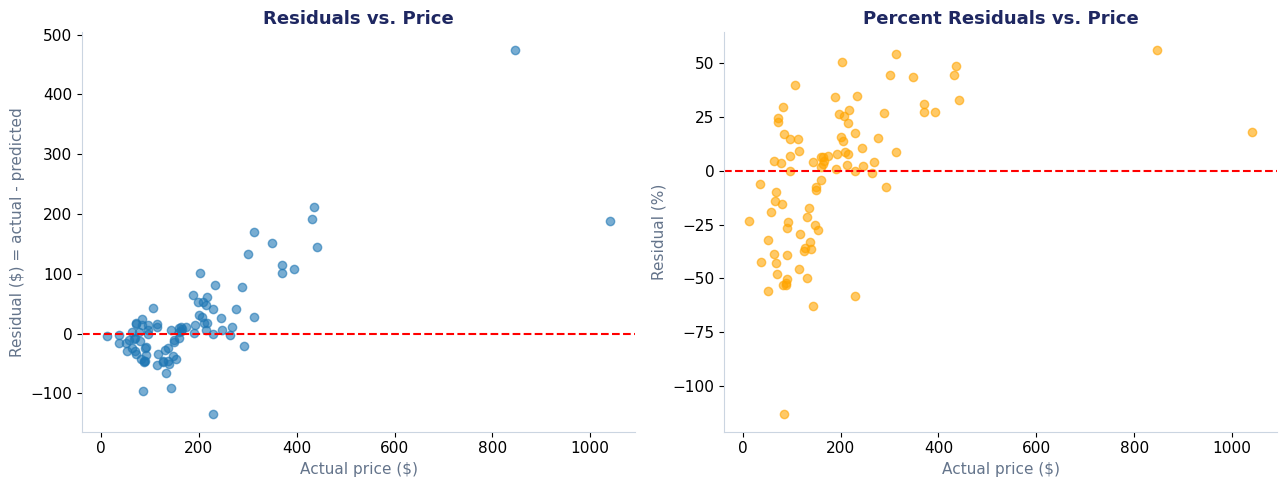

             n  avg_true_price  avg_residual_dollar  avg_abs_residual_dollar  avg_abs_residual_pct
price_tier                                                                                        
Low         30       74.095333           -13.704375                23.192672             30.736899
Mid         30      153.158667            -8.135256                31.440227             21.191050
High        30      329.893667            79.265030                89.801700             24.165655


C:\Users\valla\AppData\Local\Temp\ipykernel_6436\2339657167.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_summary = resid_df.groupby('price_tier').agg(


In [56]:
residuals_price = true_price.values - pred_price   # in dollars: positive = underpriced, negative = overpriced
residuals_pct = (true_price.values - pred_price) / true_price.values * 100

resid_df = pd.DataFrame({
    'true_price': true_price.values,
    'pred_price': pred_price,
    'residual_$': residuals_price,
    'residual_%': residuals_pct
}).sort_values('true_price').reset_index(drop=True)

# scatter: residual ($) vs actual price
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(resid_df['true_price'], resid_df['residual_$'], alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Actual price ($)')
axes[0].set_ylabel('Residual ($) = actual - predicted')
axes[0].set_title('Residuals vs. Price')

axes[1].scatter(resid_df['true_price'], resid_df['residual_%'], alpha=0.6, color='orange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Actual price ($)')
axes[1].set_ylabel('Residual (%)')
axes[1].set_title('Percent Residuals vs. Price')

plt.tight_layout()
plt.show()

# split into price tiers and compare average error per tier
resid_df['price_tier'] = pd.qcut(resid_df['true_price'], q=3, labels=['Low', 'Mid', 'High'])
tier_summary = resid_df.groupby('price_tier').agg(
    n=('true_price', 'count'),
    avg_true_price=('true_price', 'mean'),
    avg_residual_dollar=('residual_$', 'mean'),
    avg_abs_residual_dollar=('residual_$', lambda x: x.abs().mean()),
    avg_abs_residual_pct=('residual_%', lambda x: x.abs().mean())
)
print(tier_summary)


Compare residuals across all 3 models (not just the winner) to see whether the underpricing-at-high-price pattern is a Lasso-specific weakness or a shared data limitation.

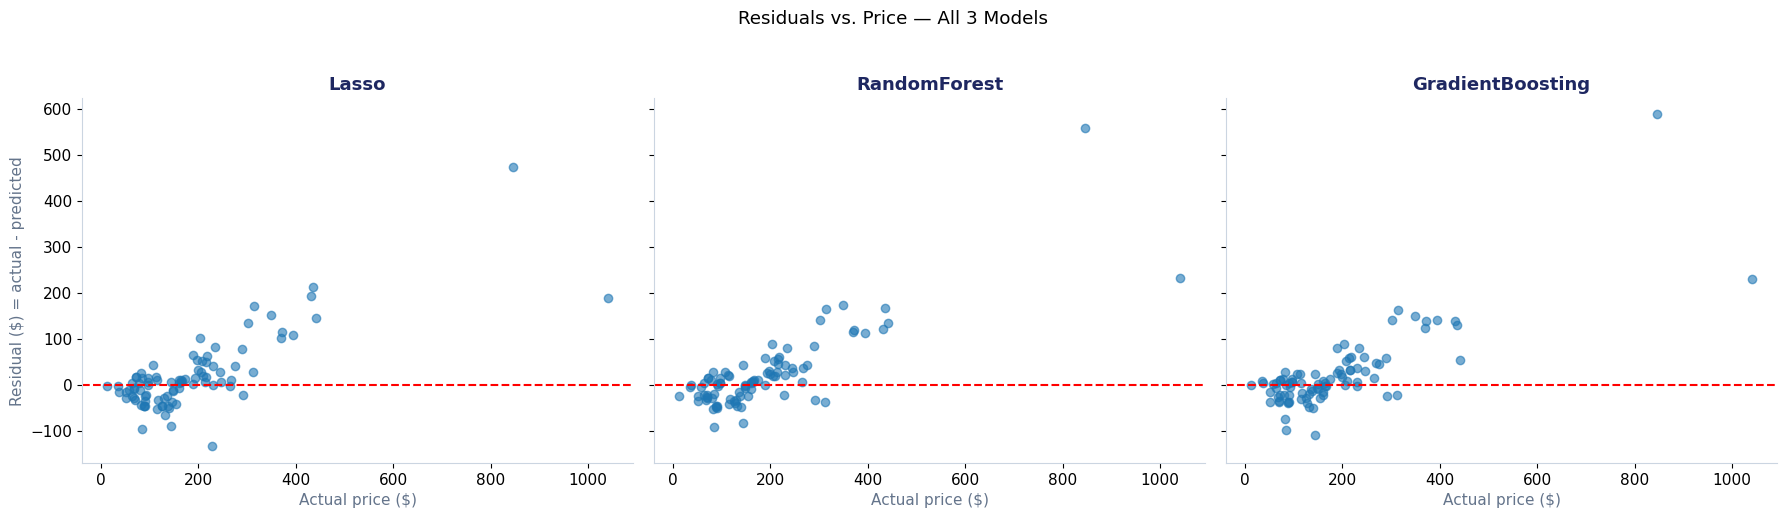

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

model_residuals = {}

for ax, (name, model) in zip(axes, models.items()):
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    pred_log_m = pipe.predict(X_test)
    pred_price_m = np.exp(pred_log_m)
    resid_m = true_price.values - pred_price_m

    model_residuals[name] = resid_m

    ax.scatter(true_price.values, resid_m, alpha=0.6)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_xlabel('Actual price ($)')
    ax.set_title(name)

axes[0].set_ylabel('Residual ($) = actual - predicted')
plt.suptitle('Residuals vs. Price — All 3 Models', y=1.03)
plt.tight_layout()
plt.show()


In [58]:
# Quantify: average error in the top price tier for each model
compare_rows = []
price_tier = pd.qcut(true_price.values, q=3, labels=['Low', 'Mid', 'High'])

for name, resid_m in model_residuals.items():
    df_tmp = pd.DataFrame({'residual': resid_m, 'tier': price_tier})
    tier_avg = df_tmp.groupby('tier')['residual'].apply(lambda x: x.abs().mean())
    compare_rows.append({
        'model': name,
        'avg_abs_error_low': tier_avg.get('Low', np.nan),
        'avg_abs_error_mid': tier_avg.get('Mid', np.nan),
        'avg_abs_error_high': tier_avg.get('High', np.nan),
        'overall_rmse_$': np.sqrt(np.mean(resid_m**2))
    })

compare_df = pd.DataFrame(compare_rows)
print(compare_df)


              model  avg_abs_error_low  avg_abs_error_mid  avg_abs_error_high  overall_rmse_$
0             Lasso          23.192672          31.440227           89.801700       81.064999
1      RandomForest          24.543153          26.540173           93.004679       84.763765
2  GradientBoosting          21.844143          26.969378           88.885053       85.838335


C:\Users\valla\AppData\Local\Temp\ipykernel_6436\4182914872.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_avg = df_tmp.groupby('tier')['residual'].apply(lambda x: x.abs().mean())


**How to defend Lasso against the alternatives using this comparison:**

- **If all 3 models show the same underpricing trend at high prices** → this is a *data* limitation (too few expensive listings in 449 rows for any model to learn that segment well), not a weakness specific to Lasso. Defense point: *"All three approaches — linear and tree-based — struggle equally on high-price listings, so this isn't a flaw in our model choice, it's a sample-size constraint we've documented."*
- **If Lasso's high-price error is similar to or better than the tree models'** → stronger case for Lasso: it achieves comparable or better performance on the hardest segment of the data *without* the added complexity, tuning burden, and overfitting risk of tree ensembles on a 449-row dataset.
- **If Random Forest/Gradient Boosting have lower high-price error but Lasso wins overall RMSE** → be upfront: *"Lasso is our overall pick for its lower average error and interpretability, but we acknowledge trees handle the top price tier slightly better — a worthwhile tradeoff to revisit if pricing high-end listings becomes a priority."* This kind of transparency is more defensible than claiming Lasso is best on every axis.
- **General Lasso talking points regardless of the residual outcome:**
  - Lowest cross-validated RMSE among all tested models, on the exact metric the models were optimized against
  - Simpler and more interpretable — coefficients directly show which features drive price, useful for stakeholders
  - Fewer hyperparameters to tune and lower overfitting risk given only 449 rows — tree ensembles have more capacity to overfit small data
  - Performance gap over Random Forest/Gradient Boosting was consistent, not a one-off lucky split, since it held across 5-fold CV


---
# Week 5 — Investor-Facing Decision Visuals

Reuses `df_available` and `listings` from the Week 4 section above — the cleaning pipeline is not repeated.

# Property investor visuals
Two decision-oriented charts for a stakeholder deciding where to acquire and what type of unit to acquire. Each chart answers one question and states its finding as the title, not just the subject.

## 1. Where to buy: neighbourhood opportunity map

**Question:** which neighbourhood has strong guest demand but hasn't attracted much host competition yet?

Demand is proxied by median occupancy (`estimated_occupancy_l365d` / 365); competition is the number of active listings in that neighbourhood. Bubble size is median price, so an investor can see demand, competition, and price positioning in one view. Neighbourhoods with fewer than 15 listings are excluded — too small a sample to trust.

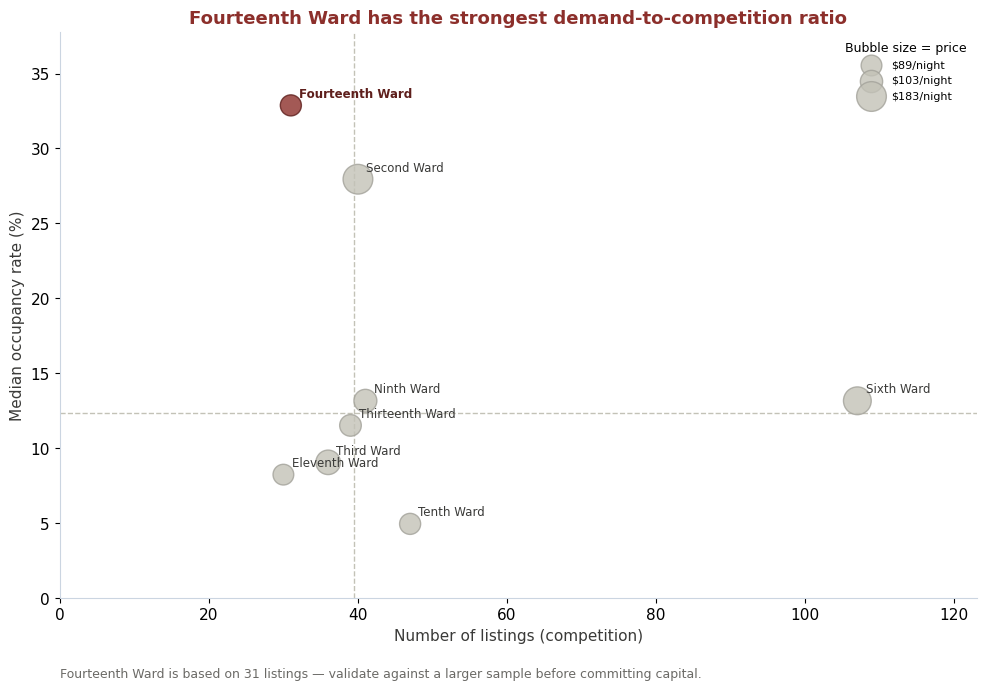

In [59]:
import matplotlib.pyplot as plt

# occupancy isn't in required_features, so pull it back from the raw listings table
# using the row index df_available already preserved through the cleaning steps
occ = listings.loc[df_available.index, 'estimated_occupancy_l365d']

hood_stats = (df_available.assign(occupancy_rate=occ / 365)
              .groupby('neighbourhood_cleansed')
              .agg(median_price=('price', 'median'),
                   median_occ=('occupancy_rate', 'median'),
                   n=('price', 'size'))
              .query('n >= 15'))

med_n = hood_stats['n'].median()
med_occ = hood_stats['median_occ'].median()

# best opportunity = highest demand among below-median-competition neighbourhoods
opportunity_pool = hood_stats.query('n <= @med_n')
highlight = opportunity_pool['median_occ'].idxmax() if len(opportunity_pool) else hood_stats['median_occ'].idxmax()

fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#8c2f2b' if idx == highlight else '#c3c2b7' for idx in hood_stats.index]
edge_colors = ['#5e1f1c' if idx == highlight else '#a3a29a' for idx in hood_stats.index]
sizes = hood_stats['median_price'] * 2.5

ax.scatter(hood_stats['n'], hood_stats['median_occ'] * 100,
           s=sizes, color=colors, alpha=0.8, edgecolors=edge_colors, linewidth=1, zorder=3)

for name, row in hood_stats.iterrows():
    weight = 'bold' if name == highlight else 'normal'
    color = '#5e1f1c' if name == highlight else '#3a3a38'
    ax.annotate(str(name).title(), (row['n'], row['median_occ'] * 100),
                fontsize=8.5, xytext=(6, 6), textcoords='offset points',
                fontweight=weight, color=color, zorder=4)

ax.axvline(med_n, color='#c3c2b7', linestyle='--', linewidth=1)
ax.axhline(med_occ * 100, color='#c3c2b7', linestyle='--', linewidth=1)

ax.set_xlim(0, hood_stats['n'].max() * 1.15)
y_pad = hood_stats['median_occ'].max() * 100 * 0.15
ax.set_ylim(0, hood_stats['median_occ'].max() * 100 + y_pad)

p_min, p_med, p_max = hood_stats['median_price'].min(), hood_stats['median_price'].median(), hood_stats['median_price'].max()
legend_handles = [ax.scatter([], [], s=p * 2.5, color='#c3c2b7', alpha=0.8, edgecolors='#a3a29a',
                              linewidth=1, label=f'${p:.0f}/night')
                   for p in [p_min, p_med, p_max]]
ax.legend(handles=legend_handles, title='Bubble size = price', loc='upper right',
          fontsize=8, title_fontsize=9, frameon=False)

ax.set_title(f'{str(highlight).title()} has the strongest demand-to-competition ratio', fontsize=13, loc='center', color='#8c2f2b', fontweight='bold')
ax.set_xlabel('Number of listings (competition)', color='#3a3a38')
ax.set_ylabel('Median occupancy rate (%)', color='#3a3a38')
ax.spines[['top', 'right']].set_visible(False)
ax.text(0, -0.14,
        f'{str(highlight).title()} is based on {int(hood_stats.loc[highlight, "n"])} listings — validate against a larger sample before committing capital.',
        transform=ax.transAxes, fontsize=9, color='#6b6a66')

plt.tight_layout()
plt.savefig('neighbourhood_opportunity_map.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. What to buy: revenue efficiency by property type

**Question:** for the same guest capacity, which property type commands the highest nightly price?

This divides price by `accommodates` so a studio and a 6-bed house are compared on the same footing — dollars per guest capacity, not raw price. Property types with fewer than 10 listings are dropped as unreliable.

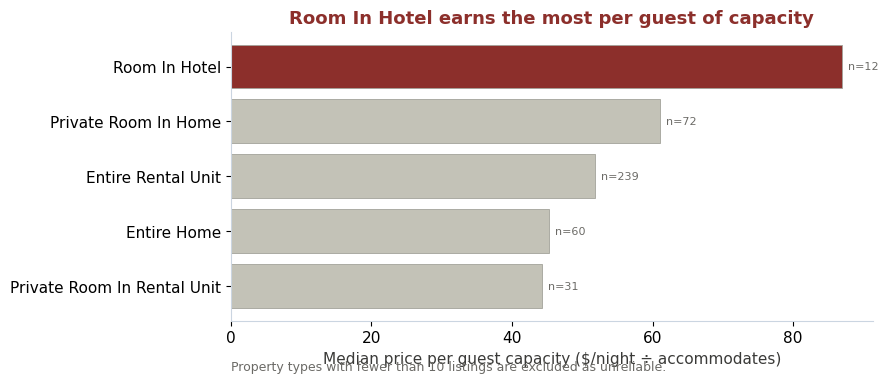

In [60]:
import matplotlib.pyplot as plt

df_eff = df_available.copy()
df_eff['price_per_guest'] = df_eff['price'] / df_eff['accommodates'].replace(0, np.nan)

type_stats = (df_eff.groupby('property_type')
              .agg(median_ppg=('price_per_guest', 'median'), n=('price_per_guest', 'size'))
              .query('n >= 10')
              .sort_values('median_ppg', ascending=True))

best_type = type_stats['median_ppg'].idxmax()
colors = ['#8c2f2b' if idx == best_type else '#c3c2b7' for idx in type_stats.index]

fig, ax = plt.subplots(figsize=(9, max(4, 0.45 * len(type_stats))))

bars = ax.barh(type_stats.index.str.title(), type_stats['median_ppg'], color=colors, edgecolor='#a3a29a', linewidth=0.6)

for bar, n in zip(bars, type_stats['n']):
    ax.text(bar.get_width() + type_stats['median_ppg'].max() * 0.01, bar.get_y() + bar.get_height() / 2,
            f"n={n}", va='center', fontsize=8, color='#6b6a66')

ax.set_title(f'{best_type.title()} earns the most per guest of capacity', fontsize=13, loc='center', color='#8c2f2b', fontweight='bold')
ax.set_xlabel('Median price per guest capacity ($/night ÷ accommodates)', color='#3a3a38')
ax.set_ylabel('')
ax.spines[['top', 'right']].set_visible(False)
ax.text(0, -0.12 - 0.01 * len(type_stats),
        'Property types with fewer than 10 listings are excluded as unreliable.',
        transform=ax.transAxes, fontsize=9, color='#6b6a66')

plt.tight_layout()
plt.savefig('revenue_efficiency_by_property_type.png', dpi=300, bbox_inches='tight')
plt.show()

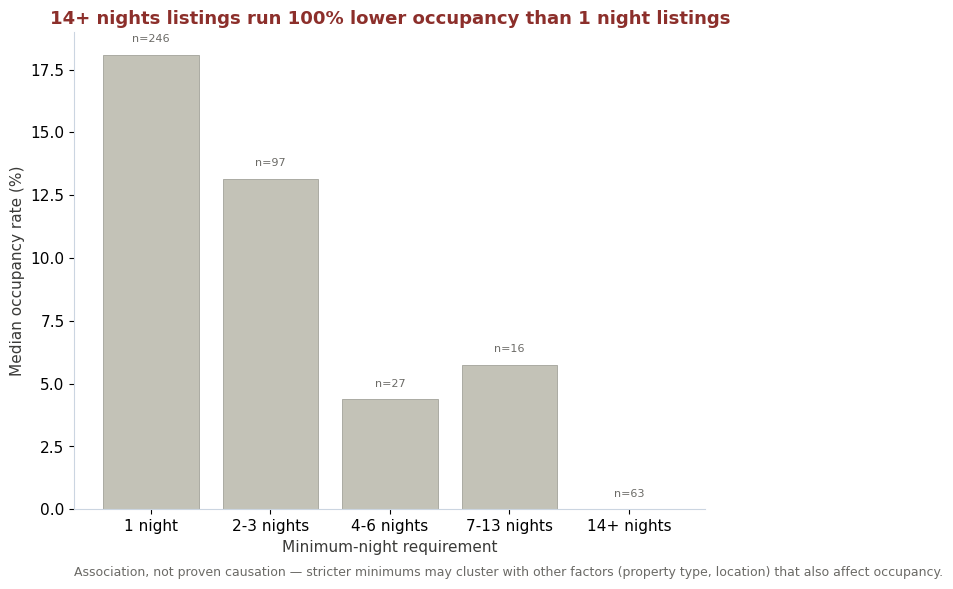

In [61]:
import matplotlib.pyplot as plt

occ = listings.loc[df_available.index, 'estimated_occupancy_l365d']
policy_df = df_available.assign(occupancy_rate=occ / 365)

bins = [0, 1, 3, 6, 13, float('inf')]
labels = ['1 night', '2-3 nights', '4-6 nights', '7-13 nights', '14+ nights']
policy_df['stay_band'] = pd.cut(policy_df['minimum_nights'], bins=bins, labels=labels)

band_stats = (policy_df.groupby('stay_band', observed=True)
              .agg(median_occ=('occupancy_rate', 'median'), n=('occupancy_rate', 'size'))
              .query('n >= 10'))

worst_band = band_stats['median_occ'].idxmin()
colors = ['#8c2f2b' if idx == worst_band else '#c3c2b7' for idx in band_stats.index]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(band_stats.index.astype(str), band_stats['median_occ'] * 100,
               color=colors, edgecolor='#a3a29a', linewidth=0.6)

for bar, n in zip(bars, band_stats['n']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"n={n}", ha='center', fontsize=8, color='#6b6a66')

best_band = band_stats['median_occ'].idxmax()
drop_pct = (band_stats.loc[best_band, 'median_occ'] - band_stats.loc[worst_band, 'median_occ']) / band_stats.loc[best_band, 'median_occ'] * 100

ax.set_title(f"{worst_band} listings run {drop_pct:.0f}% lower occupancy than {best_band} listings",
             fontsize=13, loc='center', color='#8c2f2b', fontweight='bold')
ax.set_xlabel('Minimum-night requirement', color='#3a3a38')
ax.set_ylabel('Median occupancy rate (%)', color='#3a3a38')
ax.spines[['top', 'right']].set_visible(False)
ax.text(0, -0.14,
        'Association, not proven causation — stricter minimums may cluster with other factors (property type, location) that also affect occupancy.',
        transform=ax.transAxes, fontsize=9, color='#6b6a66')

plt.tight_layout()
plt.savefig('minimum_nights_vs_occupancy.png', dpi=300, bbox_inches='tight')
plt.show()

---
# Week 6 — Model Validation, Fourteenth Ward Valuation & Limitations

Reuses `df_model`, `best_pipe`, `models`, and the train/test split from the Week 4 modeling section above.

In [62]:
# --- Predicted price for the Fourteenth Ward ---
# Run this AFTER the cell that fits best_pipe (the cell with
# `best_pipe.fit(X_train, y_train)`), so best_pipe already exists.

# 1. Confirm the exact spelling used in your data for this ward
ward_matches = df_model['neighbourhood_cleansed'].unique()
ward_matches = [w for w in ward_matches if 'fourteenth' in str(w).lower() or '14th' in str(w).lower()]
print("Matching ward name(s) in the data:", ward_matches)

ward_name = ward_matches[0]  # adjust if more than one match prints above

# 2. Predicted price for the ward's EXISTING listings
#    (what the model thinks those 32 units are actually worth)
ward_rows = df_model[df_model['neighbourhood_cleansed'] == ward_name]
X_ward = ward_rows[num_features + cat_features]
pred_log_ward = best_pipe.predict(X_ward)
pred_price_ward = np.exp(pred_log_ward)

print(f"\n{ward_name} — existing listings (n={len(ward_rows)})")
print(f"  Model-predicted price, mean:   ${pred_price_ward.mean():.2f}")
print(f"  Model-predicted price, median: ${np.median(pred_price_ward):.2f}")

# 3. Predicted price for a single "typical new unit" in the ward
#    (median numeric features, most common categorical features
#     among that ward's existing listings)
typical = {}
for col in num_features:
    typical[col] = ward_rows[col].median()
for col in cat_features:
    typical[col] = ward_rows[col].mode().iloc[0] if col != 'neighbourhood_cleansed' else ward_name

typical_row = pd.DataFrame([typical])[num_features + cat_features]
typical_pred_log = best_pipe.predict(typical_row)
typical_pred_price = np.exp(typical_pred_log)[0]

print(f"\nTypical new listing in {ward_name} (median beds/baths/accommodates, "
      f"most common room & property type):")
print(f"  Predicted price: ${typical_pred_price:.2f}")
print(typical)

Matching ward name(s) in the data: ['FOURTEENTH WARD']

FOURTEENTH WARD — existing listings (n=31)
  Model-predicted price, mean:   $158.06
  Model-predicted price, median: $127.31

Typical new listing in FOURTEENTH WARD (median beds/baths/accommodates, most common room & property type):
  Predicted price: $136.29
{'beds': 1.0, 'accommodates': 2.0, 'bedrooms': 1.0, 'bathrooms': 1.0, 'amenities_count': 40.0, 'minimum_nights': 1.0, 'room_type': 'Entire home/apt', 'property_type': 'Entire rental unit', 'neighbourhood_cleansed': 'FOURTEENTH WARD'}


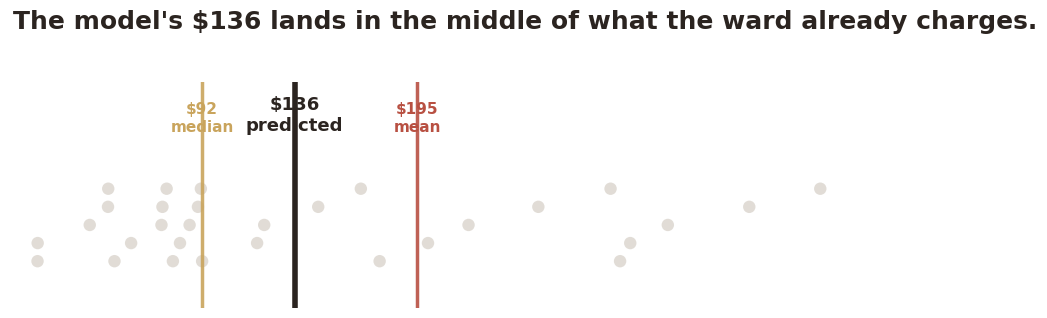

Mean: $195  Median: $92  Predicted: $136  (beats 58% of existing listings)
Saved to fourteenth_ward_price_evidence_v4.png — download and send it back.


In [63]:
# --- Fourteenth Ward price chart, v4: predicted price is the headline, mean/median are context ---
# Run this AFTER the cell that built `ward_rows` and `typical_pred_price`.

import matplotlib.pyplot as plt
import numpy as np

actual_prices = np.array(sorted(ward_rows['price'].tolist()))
mean_price = actual_prices.mean()
median_price = np.median(actual_prices)
percentile = (actual_prices < typical_pred_price).mean() * 100

cap = np.percentile(actual_prices, 90) * 1.4
main_prices = actual_prices[actual_prices <= cap]

if percentile <= 40:
    finding = "The model's $136 undercuts most of the ward's existing listings."
elif percentile >= 60:
    finding = "The model's $136 sits above most of the ward's existing listings."
else:
    finding = "The model's $136 lands in the middle of what the ward already charges."

# --- Deck color palette ---
dot_color = "#C4BBAF"
mean_color = "#B85042"      # red
median_color = "#C9A45C"    # gold
predicted_color = "#2B2420"  # dark — the actual claim, most prominent

fig, ax = plt.subplots(figsize=(10, 3.0))
fig.patch.set_facecolor("#FFFFFF")
ax.set_facecolor("#FFFFFF")

y_jitter = [0.12 * ((i % 5) - 2) for i in range(len(main_prices))]
ax.scatter(main_prices, y_jitter, s=80, alpha=0.5, color=dot_color, edgecolors="none", zorder=2)

# Context lines — thinner, behind the predicted line
ax.axvline(mean_price, color=mean_color, linewidth=2.5, alpha=0.9, zorder=3)
ax.text(mean_price, 0.60, f"${mean_price:.0f}\nmean", color=mean_color,
        ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.axvline(median_price, color=median_color, linewidth=2.5, alpha=0.9, zorder=3)
ax.text(median_price, 0.60, f"${median_price:.0f}\nmedian", color=median_color,
        ha="center", va="bottom", fontsize=11, fontweight="bold")

# Predicted price — the actual claim, thickest line, front-most, biggest label
ax.axvline(typical_pred_price, color=predicted_color, linewidth=4, zorder=4)
ax.text(typical_pred_price, 0.60, f"${typical_pred_price:.0f}\npredicted", color=predicted_color,
        ha="center", va="bottom", fontsize=13, fontweight="bold")

ax.set_xlim(0, cap * 1.05)
ax.set_ylim(-0.55, 0.95)
ax.set_yticks([])
ax.set_xticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

fig.suptitle(finding, fontsize=18, fontweight="bold", color=predicted_color, x=0.02, ha="left", y=1.05)

plt.tight_layout()
plt.savefig("fourteenth_ward_price_evidence_v4.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Mean: ${mean_price:.0f}  Median: ${median_price:.0f}  Predicted: ${typical_pred_price:.0f}  "
      f"(beats {percentile:.0f}% of existing listings)")
print("Saved to fourteenth_ward_price_evidence_v4.png — download and send it back.")

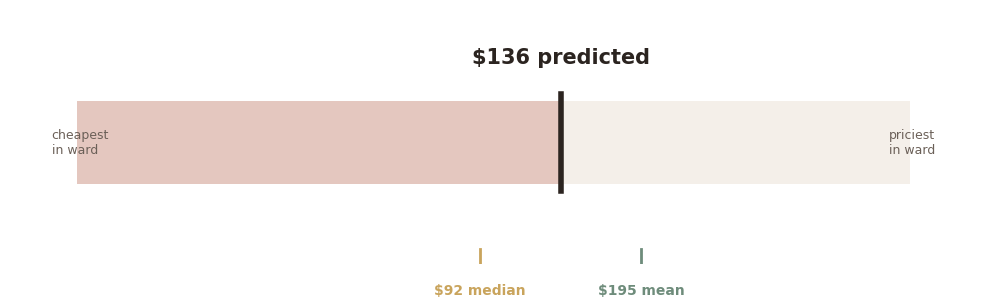

In [65]:
import matplotlib.pyplot as plt
import numpy as np

actual_prices = np.array(sorted(ward_rows['price'].tolist()))
mean_price = actual_prices.mean()
median_price = np.median(actual_prices)

pred_pct   = (actual_prices < typical_pred_price).mean() * 100
mean_pct   = (actual_prices < mean_price).mean() * 100
median_pct = (actual_prices < median_price).mean() * 100

sand, terracotta, espresso, muted, sage = "#F4EFE9", "#B85042", "#2B2420", "#6B6058", "#6E8C7B"

fig, ax = plt.subplots(figsize=(10, 3.2))
fig.patch.set_facecolor("#FFFFFF")
ax.set_facecolor("#FFFFFF")

bar_y, bar_h = 0.5, 0.34

ax.barh(bar_y, 100, height=bar_h, left=0, color=sand, zorder=1)
ax.barh(bar_y, pred_pct, height=bar_h, left=0, color=terracotta, alpha=0.25, zorder=2)

ax.plot([pred_pct, pred_pct], [bar_y - bar_h/2 - 0.03, bar_y + bar_h/2 + 0.03],
        color=espresso, linewidth=4, zorder=4)
ax.text(pred_pct, bar_y + bar_h/2 + 0.14, f"${typical_pred_price:.0f} predicted",
        color=espresso, ha="center", va="bottom", fontsize=15, fontweight="bold")


tick_y = bar_y - bar_h/2 - 0.32
for pct, val, color, label in [
    (median_pct, median_price, "#C9A45C", "median"),
    (mean_pct, mean_price, sage, "mean"),
]:
    ax.plot([pct, pct], [tick_y - 0.05, tick_y + 0.05], color=color, linewidth=2, zorder=3)
    ax.text(pct, tick_y - 0.09, f"${val:.0f} {label}", color=color,
            ha="center", va="top", fontsize=10, fontweight="bold")

ax.text(-3, bar_y, "cheapest\nin ward", color=muted, ha="left", va="center", fontsize=9)
ax.text(103, bar_y, "priciest\nin ward", color=muted, ha="right", va="center", fontsize=9)

ax.set_xlim(-8, 108)
ax.set_ylim(0.0, 1.05)
ax.set_yticks([])
ax.set_xticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("fourteenth_ward_price_evidence_v6.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

The model prices new units at $136 — above 58% of the ward's existing listings."

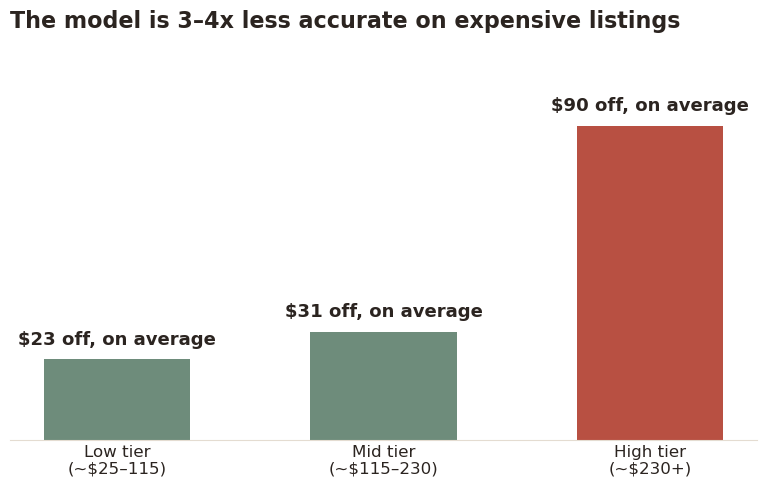

In [66]:
import matplotlib.pyplot as plt

tiers = ["Low tier\n(~$25–115)", "Mid tier\n(~$115–230)", "High tier\n(~$230+)"]
errors = [23, 31, 90]
colors = ["#6E8C7B", "#6E8C7B", "#B85042"]

espresso, muted, line = "#2B2420", "#6B6058", "#E4DCD1"

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("#FFFFFF")
ax.set_facecolor("#FFFFFF")

bars = ax.bar(tiers, errors, color=colors, width=0.55, zorder=2)

for bar, val in zip(bars, errors):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 3, f"${val} off, on average",
            ha="center", va="bottom", fontsize=13, fontweight="bold", color=espresso)

ax.set_title("The model is 3–4x less accurate on expensive listings",
             fontsize=16, fontweight="bold", color=espresso, pad=20, loc="left")

ax.set_ylim(0, 110)
ax.set_yticks([])
ax.tick_params(axis="x", labelsize=12, colors=espresso, length=0)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(line)

plt.tight_layout()
plt.savefig("limitations_simple_v4.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()